In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import torch

print("Torch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch Version: 2.10.0+cu128
CUDA Available: True
GPU: Tesla T4


In [2]:
!git clone https://github.com/csguoh/MambaIR.git

Cloning into 'MambaIR'...
remote: Enumerating objects: 578, done.
remote: Counting objects: 100% (265/265), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 578 (delta 226), reused 153 (delta 153), pack-reused 313 (from 2)
Receiving objects: 100% (578/578), 13.85 MiB | 46.79 MiB/s, done.
Resolving deltas: 100% (297/297), done.


In [3]:
%cd MambaIR
!ls


/kaggle/working/MambaIR
analysis  basicsr   environment.yaml  LICENSE  README.md      requirements.txt
assets	  datasets  experiments       options  realDenoising  setup.py


In [4]:
!ls


analysis  basicsr   environment.yaml  LICENSE  README.md      requirements.txt
assets	  datasets  experiments       options  realDenoising  setup.py


In [5]:
!cat requirements.txt

# This file may be used to create an environment using:
# $ conda create --name <env> --file <this file>
# platform: linux-64
_libgcc_mutex=0.1=main
_openmp_mutex=5.1=1_gnu
absl-py=2.1.0=pypi_0
addict=2.4.0=pypi_0
blas=1.0=mkl
brotli-python=1.0.9=py38h6a678d5_7
bzip2=1.0.8=h7b6447c_0
ca-certificates=2023.12.12=h06a4308_0
cachetools=5.3.2=pypi_0
causal-conv1d=1.0.0=pypi_0
certifi=2023.11.17=py38h06a4308_0
cffi=1.16.0=py38h5eee18b_0
charset-normalizer=2.0.4=pyhd3eb1b0_0
cmake=3.28.1=pypi_0
contourpy=1.1.1=pypi_0
cryptography=41.0.7=py38hdda0065_0
cuda-cudart=11.7.99=0
cuda-cupti=11.7.101=0
cuda-libraries=11.7.1=0
cuda-nvrtc=11.7.99=0
cuda-nvtx=11.7.91=0
cuda-runtime=11.7.1=0
cycler=0.12.1=pypi_0
einops=0.7.0=pypi_0
ffmpeg=4.3=hf484d3e_0
filelock=3.13.1=py38h06a4308_0
fonttools=4.47.2=pypi_0
freetype=2.12.1=h4a9f257_0
fsspec=2023.12.2=pypi_0
future=0.18.3=pypi_0
giflib=5.2.1=h5eee18b_3
gmp=6.2.1=h295c915_3
gmpy2=2.1.2=py38heeb90bb_0
gnutls=3.6.15=he1e5248_0
google-auth=2.27.0=pypi_0
googl

In [6]:
!find . -maxdepth 2 -type f | head -50

./assets/imgsli5.png
./assets/erf.png
./assets/imgsli2.png
./assets/imgsli3.png
./assets/pipeline.png
./assets/classicSR.png
./assets/car.png
./assets/imgsli4.png
./assets/imgsli1.png
./assets/logo.png
./assets/lightSR.png
./assets/visual_results.png
./assets/imgsli6.png
./assets/gaussian_dn.png
./requirements.txt
./basicsr/train.py
./basicsr/version.py
./basicsr/__init__.py
./basicsr/test.py
./setup.py
./realDenoising/test_real_denoising_dnd.py
./realDenoising/evaluate_sidd.m
./realDenoising/setup.py
./realDenoising/README.md
./realDenoising/test_real_denoising_sidd.py
./realDenoising/utils.py
./realDenoising/VERSION
./realDenoising/setup.cfg
./environment.yaml
./README.md
./analysis/utils_fvcore.py
./analysis/flops_param.py
./analysis/flops_param_fvcore.py
./analysis/erf.py
./analysis/flops_param_thop.py
./LICENSE
./datasets/README.md
./.git/packed-refs
./.git/config
./.git/index
./.git/description
./.git/HEAD


In [8]:
%cd /kaggle/working/MambaIR
!pip install -r requirements.txt

/kaggle/working/MambaIR
ERROR: Invalid requirement: '_libgcc_mutex=0.1=main': Expected package name at the start of dependency specifier
    _libgcc_mutex=0.1=main
    ^ (from line 4 of requirements.txt)
Hint: = is not a valid operator. Did you mean == ?


In [9]:
%cd /kaggle/working/MambaIR

!pip install einops timm lmdb pyyaml opencv-python scikit-image tqdm yacs

/kaggle/working/MambaIR
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 5.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 86.2 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26

In [10]:
%cd /kaggle/working/MambaIR
!python setup.py develop

/kaggle/working/MambaIR
Traceback (most recent call last):
  File "/kaggle/working/MambaIR/setup.py", line 140, in <module>
    write_version_py()
  File "/kaggle/working/MambaIR/setup.py", line 69, in write_version_py
    with open('VERSION', 'r') as f:
         ^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'VERSION'


In [11]:
import basicsr

print("BasicSR imported successfully")

ModuleNotFoundError: No module named 'mamba_ssm'

In [12]:
!grep -R "mamba_ssm" -n /kaggle/working/MambaIR | head -20

grep: /kaggle/working/MambaIR/basicsr/archs/mambairv2_arch.py:7:from mamba_ssm.ops.selective_scan_interface import selective_scan_fn, selective_scan_ref
/kaggle/working/MambaIR/basicsr/archs/__pycache__/mambairv2_arch.cpython-312.pyc: binary file matches/kaggle/working/MambaIR/basicsr/archs/mambairv2light_arch.py:7:from mamba_ssm.ops.selective_scan_interface import selective_scan_fn, selective_scan_ref

/kaggle/working/MambaIR/basicsr/archs/mambair_arch.py:11:from mamba_ssm.ops.selective_scan_interface import selective_scan_fn, selective_scan_ref
/kaggle/working/MambaIR/realDenoising/basicsr/models/archs/mambairunet_arch.py:9:from mamba_ssm.ops.selective_scan_interface import selective_scan_fn, selective_scan_ref
/kaggle/working/MambaIR/README.md:214:(**Note:** If you uses a newer cuda version, say 12.x, you may refer to the official github page of [causal_conv_1d](https://github.com/Dao-AILab/causal-conv1d/releases) and [mamba_ssm](https://github.com/state-spaces/mamba/releases/tag/v2

In [15]:
!cat /kaggle/working/MambaIR/environment.yaml | head -100

name: mambair
channels:
  - pytorch
  - nvidia
  - defaults
dependencies:
  - _libgcc_mutex=0.1=main
  - _openmp_mutex=5.1=1_gnu
  - blas=1.0=mkl
  - brotli-python=1.0.9=py38h6a678d5_7
  - bzip2=1.0.8=h5eee18b_5
  - ca-certificates=2023.12.12=h06a4308_0
  - certifi=2024.2.2=py38h06a4308_0
  - charset-normalizer=2.0.4=pyhd3eb1b0_0
  - cuda-cudart=11.7.99=0
  - cuda-cupti=11.7.101=0
  - cuda-libraries=11.7.1=0
  - cuda-nvrtc=11.7.99=0
  - cuda-nvtx=11.7.91=0
  - cuda-runtime=11.7.1=0
  - ffmpeg=4.3=hf484d3e_0
  - filelock=3.13.1=py38h06a4308_0
  - freetype=2.12.1=h4a9f257_0
  - gmp=6.2.1=h295c915_3
  - gmpy2=2.1.2=py38heeb90bb_0
  - gnutls=3.6.15=he1e5248_0
  - idna=3.4=py38h06a4308_0
  - intel-openmp=2023.1.0=hdb19cb5_46306
  - jinja2=3.1.3=py38h06a4308_0
  - jpeg=9e=h5eee18b_1
  - lame=3.100=h7b6447c_0
  - lcms2=2.12=h3be6417_0
  - ld_impl_linux-64=2.38=h1181459_1
  - lerc=3.0=h295c915_0
  - libcublas=11.10.3.66=0
  - libcufft=10.7.2.124=h4fbf590_0
  - libcufile=1.8.1.2=0
  - libcurand

In [16]:
import torch

print(torch.__version__)
print(torch.version.cuda)

2.10.0+cu128
12.8


In [17]:
!grep -n "pretrained" README.md

89:- **2024-07-04**: The pretrained weight for **Guassian Color Image Denosing** as well as **JPEG Compression Artifact Reduction** are now available [here](#model_summary). The performance of these models is futher improved than the reported one in the paper. And we will update the Arxiv version in the future. Enjoy these new models! :yum:
338:1. Please download the corresponding testing datasets and put them in the folder datasets/SR. Download the corresponding models and put them in the folder `experiments/pretrained`.
365:2. Download the corresponding models and put them in the folder `experiments/pretrained_models`.
380:2. Download the corresponding models and put them in the folder `experiments/pretrained_models`.


In [18]:
!sed -n '300,420p' README.md

```
# train on denosing15
python -m torch.distributed.launch --nproc_per_node=8 --master_port=2414 basicsr/train.py -opt options/train/mambairv2/train_MambaIRv2_ColorDN_level15.yml --launcher pytorch
```


3. Run the script then you can find the generated experimental logs in the folder `./experiments`.



### Train on JPEG Compression Artifact Reduction


1. Download the corresponding training datasets [here](#datasets) and put them in the folder `./datasets/DFWB_CAR`. Download the testing datasets and put them in the folder `./datasets/JPEG_CAR`.


2. Follow the instructions below to begin training:


```
# train on jpeg10
python -m torch.distributed.launch --nproc_per_node=8 --master_port=2414 basicsr/train.py -opt options/train/mambairv2/train_MambaIRv2_CAR_q10.yml --launcher pytorch

# train on jpeg30
python -m torch.distributed.launch --nproc_per_node=8 --master_port=2414 basicsr/train.py -opt options/train/mambairv2/train_MambaIRv2_CAR_q30.yml --launcher pytorch

# train on jpeg

In [19]:
!sed -n '320,420p' README.md

# train on jpeg10
python -m torch.distributed.launch --nproc_per_node=8 --master_port=2414 basicsr/train.py -opt options/train/mambairv2/train_MambaIRv2_CAR_q10.yml --launcher pytorch

# train on jpeg30
python -m torch.distributed.launch --nproc_per_node=8 --master_port=2414 basicsr/train.py -opt options/train/mambairv2/train_MambaIRv2_CAR_q30.yml --launcher pytorch

# train on jpeg40
python -m torch.distributed.launch --nproc_per_node=8 --master_port=2414 basicsr/train.py -opt options/train/mambairv2/train_MambaIRv2_CAR_q40.yml --launcher pytorch
```

3. Run the script then you can find the generated experimental logs in the folder `./experiments`.



## <a name="testing"></a> :smile: Testing

### Test on SR

1. Please download the corresponding testing datasets and put them in the folder datasets/SR. Download the corresponding models and put them in the folder `experiments/pretrained`.

2. Follow the instructions below to begin testing our MambaIRv2 model.
```
# test for image SR (we

In [20]:
!find options -type f | head -100

options/test/mambair/test_MambaIR_ColorDN_level50.yml
options/test/mambair/test_MambaIR_CAR_q40.yml
options/test/mambair/test_MambaIR_SR_x2.yml
options/test/mambair/test_MambaIR_lightSR_x2.yml
options/test/mambair/test_MambaIR_lightSR_x4.yml
options/test/mambair/test_MambaIR_SR_x3.yml
options/test/mambair/test_MambaIR_ColorDN_level25.yml
options/test/mambair/test_MambaIR_SR_x4.yml
options/test/mambair/test_MambaIR_CAR_q30.yml
options/test/mambair/test_MambaIR_lightSR_x3.yml
options/test/mambair/test_MambaIR_ColorDN_level15.yml
options/test/mambair/test_MambaIR_CAR_q10.yml
options/test/mambairv2/test_MambaIRv2_SRSmall_x4.yml
options/test/mambairv2/test_MambaIRv2_CAR_q10.yml
options/test/mambairv2/test_MambaIRv2_SRSmall_x3.yml
options/test/mambairv2/test_MambaIRv2_ColorDN_level15.yml
options/test/mambairv2/test_MambaIRv2_SR_x2.yml
options/test/mambairv2/test_MambaIRv2_SRSmall_x2.yml
options/test/mambairv2/test_MambaIRv2_SR_x4.yml
options/test/mambairv2/test_MambaIRv2_CAR_q40.yml
options/

In [24]:
!find . -name "*.pth"

In [26]:
!find . -name "*.pth"

In [28]:
!grep -n "Model Summary" README.md



!sed -n '250,340p' README.md



!sed -n '340,420p' README.md

49:- [Model Summary](#model_summary)
115:## <a name="model_summary"></a> :page_with_curl: Model Summary


| Task                                          |                         Training Set                         |                         Testing Set                          |                        Visual Results(v2)                        |
| :-------------------------------------------- | :----------------------------------------------------------: | :----------------------------------------------------------: | :----------------------------------------------------------: |
| image SR                                      | [DIV2K](https://data.vision.ee.ethz.ch/cvl/DIV2K/) (800 training images) +  [Flickr2K](https://cv.snu.ac.kr/research/EDSR/Flickr2K.tar) (2650 images) [complete dataset DF2K [download](https://drive.google.com/file/d/1TubDkirxl4qAWelfOnpwaSKoj3KLAIG4/view?usp=share_link)] | Set5 + Set14 + BSD100 + Urban100 + Manga109 [[download](https://drive.google.com/file/d/

In [29]:
!grep -n "pretrained_models" README.md -A 50
!grep -n ".pth" README.md -A 30
!grep -n "Google Drive" README.md -A 50

365:2. Download the corresponding models and put them in the folder `experiments/pretrained_models`.
366-
367-3. Follow the instructions below to begin testing our model.
368-
369-```
370-# test on denosing15
371-python basicsr/test.py -opt options/test/mambairv2/test_MambaIRv2_ColorDN_level15.yml
372-```
373-
374-
375-
376-
377-### Test on JPEG Compression Artifact Reduction
378-1. Please download the corresponding testing datasets and put them in the folder `datasets/JPEG_CAR`. 
379-
380:2. Download the corresponding models and put them in the folder `experiments/pretrained_models`.
381-
382-3. Follow the instructions below to begin testing our model.
383-
384-```
385-# test on jpeg10
386-python basicsr/test.py -opt options/test/mambairv2/test_MambaIRv2_CAR_q10.yml
387-
388-# test on jpeg30
389-python basicsr/test.py -opt options/test/mambairv2/test_MambaIRv2_CAR_q30.yml
390-
391-# test on jpeg40
392-python basicsr/test.py -opt options/test/mambairv2/test_MambaIRv2_CAR_q40.yml
393-``

In [30]:
!grep -n "releases" README.md
!grep -n "download" README.md | head -100

139:| MambaIRv2_light2 | lightSR x2       | Urban100   |  33.26 | 0.9378    | [link](https://github.com/csguoh/MambaIR/releases/tag/v1.0)      | [link]()     |
140:| MambaIRv2_light3 | lightSR x3       | Urban100   |  29.01 | 0.8689    | [link](https://github.com/csguoh/MambaIR/releases/tag/v1.0)      | [link]()     |
141:| MambaIRv2_light4 | lightSR x4       | Urban100   | 26.82 | 0.8079  | [link](https://github.com/csguoh/MambaIR/releases/tag/v1.0)      | [link]()     |
142:| MambaIRv2_SR2 | classicSR x2       | Urban100   |  34.49 | 0.9468    | [link](https://github.com/csguoh/MambaIR/releases/tag/v1.0)      | [link]()     |
143:| MambaIRv2_SR3 | classicSR x3      | Urban100   | 30.28 | 0.8905    | [link](https://github.com/csguoh/MambaIR/releases/tag/v1.0)      | [link]()     |
144:| MambaIRv2_SR4 | classicSR x4     | Urban100   |  27.89 | 0.8344    | [link](https://github.com/csguoh/MambaIR/releases/tag/v1.0)      | [link]()     |
145:| MambaIRv2_guassian15 | Guassian Denoising | 

In [1]:
!find /kaggle/working/MambaIR -name "*.pth"

find: ‘/kaggle/working/MambaIR’: No such file or directory


In [1]:
!pwd
!ls
!ls /kaggle/working

/kaggle/working


In [2]:
!find /kaggle/working -maxdepth 2 -type d

/kaggle/working
/kaggle/working/.virtual_documents


In [6]:
!find /kaggle -type d -name "*Mamba*"

In [7]:
!find /kaggle -type f -name "*.pth"

In [8]:
%cd /kaggle/working

!git clone https://github.com/csguoh/MambaIR.git

/kaggle/working
Cloning into 'MambaIR'...
remote: Enumerating objects: 578, done.
remote: Counting objects: 100% (265/265), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 578 (delta 226), reused 153 (delta 153), pack-reused 313 (from 2)
Receiving objects: 100% (578/578), 13.85 MiB | 48.39 MiB/s, done.
Resolving deltas: 100% (297/297), done.


In [9]:
!ls /kaggle/working

MambaIR


In [10]:
!ls /kaggle/working/MambaIR

analysis  basicsr   environment.yaml  LICENSE  README.md      requirements.txt
assets	  datasets  experiments       options  realDenoising  setup.py


In [11]:
%cd /kaggle/working/MambaIR

!find . -name "*.pth"

/kaggle/working/MambaIR


In [13]:
!find /kaggle -name "*.pth" 2>/dev/null

In [14]:
!find /kaggle/input/mambairv2-pretrained-weights -name "*.pth"

find: ‘/kaggle/input/mambairv2-pretrained-weights’: No such file or directory


In [15]:
!ls /kaggle/input


datasets


In [16]:
!find /kaggle/input -name "*.pth"

/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights/mambairv2_classicSR_Base_x3 (1).pth
/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights/mambairv2_jpeg_q10.pth
/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights/mambairv2_jpeg_q40.pth
/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights/mambairv2_jpeg_q30.pth
/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights/mambairv2_classicSR_Base_x2.pth
/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights/mambairv2_ColorDN_15.pth
/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights/mambairv2_classicSR_Large_x4.pth


In [19]:
!mkdir -p /kaggle/working/MambaIR/experiments/pretrained_models

In [20]:
!cp "/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights/"*.pth \
"/kaggle/working/MambaIR/experiments/pretrained_models/"

In [21]:
!ls /kaggle/working/MambaIR/experiments/pretrained_models

 mambairv2_classicSR_Base_x2.pth        mambairv2_jpeg_q10.pth
'mambairv2_classicSR_Base_x3 (1).pth'   mambairv2_jpeg_q30.pth
 mambairv2_classicSR_Large_x4.pth       mambairv2_jpeg_q40.pth
 mambairv2_ColorDN_15.pth	        README.md


In [22]:
!cat /kaggle/working/MambaIR/options/test/mambairv2/test_MambaIRv2_SR_x2.yml | grep pretrain

  pretrain_network_g: /data2/guohang/pretrained/mambairv2/mambairv2_classicSR_Base_x2.pth


In [24]:
!sed -i 's|/data2/guohang/pretrained/mambairv2/mambairv2_classicSR_Base_x2.pth|/kaggle/working/MambaIR/experiments/pretrained_models/mambairv2_classicSR_Base_x2.pth|g' \
/kaggle/working/MambaIR/options/test/mambairv2/test_MambaIRv2_SR_x2.yml

In [26]:
!sed -i 's|/data2/guohang/pretrained/mambairv2/mambairv2_classicSR_Base_x2.pth|/kaggle/working/MambaIR/experiments/pretrained_models/mambairv2_classicSR_Base_x2.pth|g' \
/kaggle/working/MambaIR/options/test/mambairv2/test_MambaIRv2_SR_x2.yml

In [27]:
!grep pretrain_network_g \
/kaggle/working/MambaIR/options/test/mambairv2/test_MambaIRv2_SR_x2.yml

  pretrain_network_g: /kaggle/working/MambaIR/experiments/pretrained_models/mambairv2_classicSR_Base_x2.pth


In [28]:
%cd /kaggle/working/MambaIR

!python basicsr/test.py \
-opt options/test/mambairv2/test_MambaIRv2_SR_x2.yml

/kaggle/working/MambaIR
Traceback (most recent call last):
  File "/kaggle/working/MambaIR/basicsr/test.py", line 9, in <module>
    from basicsr.data import build_dataloader, build_dataset
  File "/kaggle/working/MambaIR/basicsr/__init__.py", line 1, in <module>
    from .archs import *
  File "/kaggle/working/MambaIR/basicsr/archs/__init__.py", line 16, in <module>
    _arch_modules = [importlib.import_module(f'basicsr.archs.{file_name}') for file_name in arch_filenames]
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/importlib/__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/MambaIR/basicsr/archs/mambairv2_arch.py", line 7, in <module>
    from mamba_ssm.ops.selective_scan_interface import selective_scan_fn, selective_scan_ref
ModuleNotFoundError: No module named 'mamba_ssm'


In [29]:
!pip install causal-conv1d --no-cache-dir

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 250.5 MB/s eta 0:00:00 0:00:01
  error: subprocess-exited-with-error
  
  × Building wheel for causal-conv1d (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for causal-conv1d
Failed to build causal-conv1d
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (causal-conv1d)


In [32]:
!pip install mamba-ssm --no-cache-dir

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 12.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [33]:
import torch
import sys

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA:", torch.version.cuda)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch: 2.10.0+cu128
CUDA: 12.8


In [34]:
!pip install mamba-ssm --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 48.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 63.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.7/327.7 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 109.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 26.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 66.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.8/897.8 kB 61.0 MB/s eta 0:00:00
  Created wheel for mamba-ssm: filename=mamba_ssm-2.3.2.post1-cp312-cp312-linux_x86_64.whl size=322288410 sha256=7a67070c1e7e99c95abd1319623f044e8a1b3fb46f774bfdea949f0a4fc79638
  Stored in directory: /root/.cache/pip/wheels/da/67/03/99148d6eeaa4ec2855d71295ac83bcbc8b

In [35]:
import mamba_ssm

print("Mamba installed successfully!")
print(mamba_ssm.__version__)

Mamba installed successfully!
2.3.2.post1


In [36]:
cd /kaggle/working/MambaIR

python basicsr/test.py \
-opt options/test/mambairv2/test_MambaIRv2_SR_x2.yml

SyntaxError: invalid syntax (1281357268.py, line 3)

In [37]:
!python /kaggle/working/MambaIR/basicsr/test.py -opt /kaggle/working/MambaIR/options/test/mambairv2/test_MambaIRv2_SR_x2.yml

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Disable distributed.
2026-06-12 11:38:36,770 INFO: 
  name: test_MambaIRv2_SRBase_x2
  model_type: MambaIRv2Model
  scale: 2
  num_gpu: 8
  manual_seed: 10
  datasets:[
    test_1:[
      name: Set5
      type: PairedImageDataset
      dataroot_gt: /data2/guohang/dataset/ARTSR/Set5/HR
      dataroot_lq: /data2/guohang/dataset/ARTSR/Set5/LR_bicubic/X2
      filename_tmpl: {}x2
      io_backend:[
        type: disk
      ]
      phase: test
      scale: 2
    ]
    test_2:[
      name: Set14
      type: PairedImageDataset
      dataroot_gt: /data2/guohang/dataset/ARTSR/Set14/HR
      dataroot_lq: /data2/guohang/dataset/ARTSR/Set14/LR_bicubic/X2
      filename_tmpl: {}x2
      io_backend:[
        type: disk
      ]
  

In [39]:
!find /kaggle/input -type d | grep -i "Set5"

In [40]:
!ls -R /kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights

/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights:
 mambairv2_classicSR_Base_x2.pth        mambairv2_jpeg_q10.pth
'mambairv2_classicSR_Base_x3 (1).pth'   mambairv2_jpeg_q30.pth
 mambairv2_classicSR_Large_x4.pth       mambairv2_jpeg_q40.pth
 mambairv2_ColorDN_15.pth


In [41]:
!find /kaggle/input -type d | head -100

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/poorvanshilowanshi
/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights


In [42]:
!find /kaggle/input -type f | grep -Ei "\.(jpg|jpeg|png)$"

/kaggle/input/datasets/poorvanshilowanshi/test-images/WhatsApp Image 2026-06-12 at 5.19.46 PM.jpeg


In [43]:
/kaggle/input/datasets/poorvanshilowanshi/test-images/WhatsApp Image 2026-06-12 at 5.19.46 PM.jpeg

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (724197621.py, line 1)

In [44]:
!find /kaggle/input -type f | grep -Ei "\.(jpg|jpeg|png)$"

/kaggle/input/datasets/poorvanshilowanshi/test-images/WhatsApp Image 2026-06-12 at 5.19.46 PM.jpeg


In [45]:
!ls "/kaggle/input/datasets/poorvanshilowanshi/test-images"

'WhatsApp Image 2026-06-12 at 5.19.46 PM.jpeg'


In [46]:
image_path = "/kaggle/input/datasets/poorvanshilowanshi/test-images/WhatsApp Image 2026-06-12 at 5.19.46 PM.jpeg"
print(image_path)

/kaggle/input/datasets/poorvanshilowanshi/test-images/WhatsApp Image 2026-06-12 at 5.19.46 PM.jpeg


Size: (900, 1600)
Mode: RGB


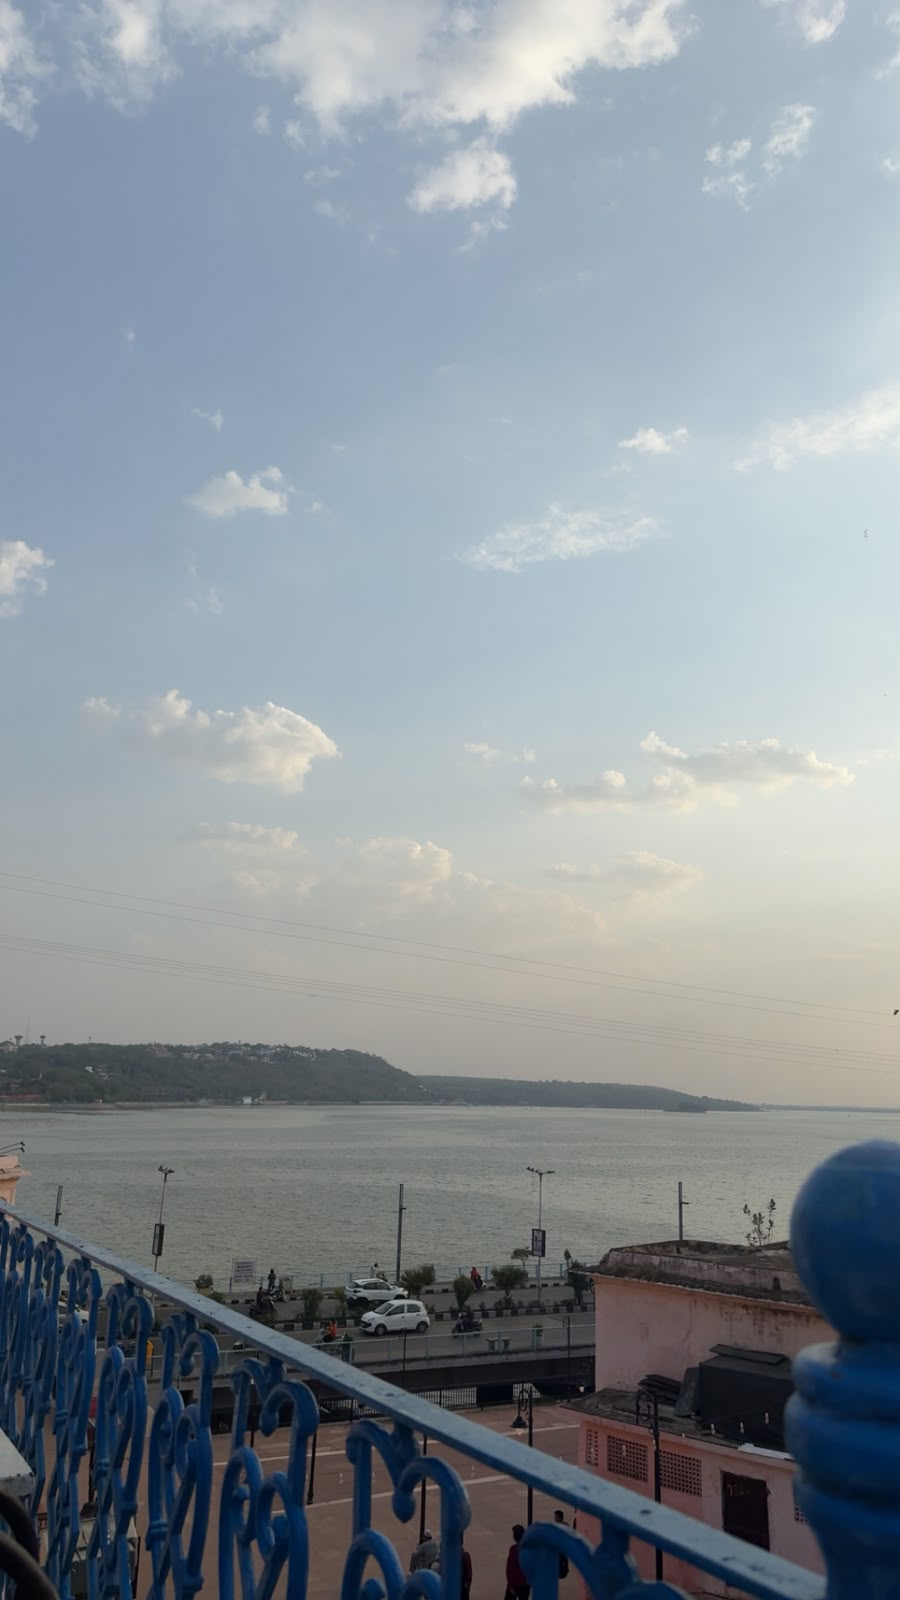

In [47]:
from PIL import Image

img = Image.open("/kaggle/input/datasets/poorvanshilowanshi/test-images/WhatsApp Image 2026-06-12 at 5.19.46 PM.jpeg")

print("Size:", img.size)
print("Mode:", img.mode)

img

In [48]:
import torch

ckpt = torch.load(
    "/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights/mambairv2_classicSR_Base_x2.pth",
    map_location="cpu"
)

print(type(ckpt))

if isinstance(ckpt, dict):
    print("Keys:", list(ckpt.keys())[:20])

<class 'dict'>
Keys: ['params']


In [49]:
!grep -n "class MambaIRv2" /kaggle/working/MambaIR/basicsr/archs/mambairv2_arch.py

783:class MambaIRv2(nn.Module):


In [50]:
from basicsr.archs.mambairv2_arch import MambaIRv2

print("Model imported successfully")

Model imported successfully


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [51]:
import inspect
from basicsr.archs.mambairv2_arch import MambaIRv2

print(inspect.signature(MambaIRv2))

(img_size=64, patch_size=1, in_chans=3, embed_dim=48, d_state=8, depths=(6, 6, 6, 6), num_heads=(4, 4, 4, 4), window_size=16, inner_rank=32, num_tokens=64, convffn_kernel_size=5, mlp_ratio=2.0, qkv_bias=True, norm_layer=<class 'torch.nn.modules.normalization.LayerNorm'>, ape=False, patch_norm=True, use_checkpoint=False, upscale=2, img_range=1.0, upsampler='', resi_connection='1conv', **kwargs)


In [52]:
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
from basicsr.archs.mambairv2_arch import MambaIRv2

# ------------------
# Build model
# ------------------
model = MambaIRv2(
    upscale=2,
    in_chans=3,
    img_size=64,
    img_range=1.0,
    embed_dim=174,
    d_state=16,
    depths

SyntaxError: incomplete input (3078266173.py, line 17)

In [53]:
ckpt = torch.load(
    "/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights/mambairv2_classicSR_Base_x2.pth",
    map_location="cpu"
)

for k in list(ckpt["params"].keys())[:20]:
    print(k)

relative_position_index_SA
conv_first.weight
conv_first.bias
patch_embed.norm.weight
patch_embed.norm.bias
layers.0.residual_group.layers.0.scale1
layers.0.residual_group.layers.0.scale2
layers.0.residual_group.layers.0.norm1.weight
layers.0.residual_group.layers.0.norm1.bias
layers.0.residual_group.layers.0.norm2.weight
layers.0.residual_group.layers.0.norm2.bias
layers.0.residual_group.layers.0.norm3.weight
layers.0.residual_group.layers.0.norm3.bias
layers.0.residual_group.layers.0.norm4.weight
layers.0.residual_group.layers.0.norm4.bias
layers.0.residual_group.layers.0.wqkv.weight
layers.0.residual_group.layers.0.wqkv.bias
layers.0.residual_group.layers.0.win_mhsa.relative_position_bias_table
layers.0.residual_group.layers.0.win_mhsa.proj.weight
layers.0.residual_group.layers.0.win_mhsa.proj.bias


In [54]:
ckpt = torch.load(
    "/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights/mambairv2_classicSR_Base_x2.pth",
    map_location="cpu"
)

print(ckpt["params"]["conv_first.weight"].shape)
print(ckpt["params"]["layers.0.residual_group.layers.0.wqkv.weight"].shape)

torch.Size([174, 3, 3, 3])
torch.Size([522, 174])


In [55]:
import torch
from basicsr.archs.mambairv2_arch import MambaIRv2

model = MambaIRv2(
    upscale=2,
    in_chans=3,
    img_size=64,
    img_range=1.0,
    embed_dim=174,
    d_state=16,
    depths=[6,6,6,6,6,6],
    num_heads=[6,6,6,6,6,6],
    window_size=16,
    inner_rank=64,
    num_tokens=128,
    convffn_kernel_size=5,
    mlp_ratio=2.0,
    upsampler="pixelshuffle",
    resi_connection="1conv"
)

ckpt = torch.load(
    "/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights/mambairv2_classicSR_Base_x2.pth",
    map_location="cpu"
)

msg = model.load_state_dict(ckpt["params"], strict=True)

print("SUCCESS!")
print(msg)

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


SUCCESS!
<All keys matched successfully>


In [57]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

# Put model in eval mode
device = torch.device("cpu")
model.to(device)
tensor = tensor.to(device)

# Load image
img = Image.open(
    "/kaggle/input/datasets/poorvanshilowanshi/test-images/WhatsApp Image 2026-06-12 at 5.19.46 PM.jpeg"
).convert("RGB")

# Convert to tensor
tensor = transforms.ToTensor()(img).unsqueeze(0).cuda()

# Inference
with torch.no_grad():
    output = model(tensor)

# Convert output back to image
output = output.squeeze(0).cpu().clamp(0,1)
output = transforms.ToPILImage()(output)

# Save result
output_path = "/kaggle/working/mambair_output_x2.png"
output.save(output_path)

print("Saved:", output_path)

# Show before / after
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Input")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(output)
plt.title("MambaIRv2 x2 Output")
plt.axis("off")

plt.show()

OutOfMemoryError: CUDA out of memory. Tried to allocate 1.39 GiB. GPU 0 has a total capacity of 14.56 GiB of which 659.81 MiB is free. Including non-PyTorch memory, this process has 13.92 GiB memory in use. Of the allocated memory 13.75 GiB is allocated by PyTorch, and 42.50 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [60]:
from PIL import Image

img = Image.open("/kaggle/working/test_small.png").convert("RGB")

img = img.resize((256, 256))

img.save("/kaggle/working/test_small.png")

print(img.size)

(256, 256)


In [1]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

print("GPU cleared")

GPU cleared


In [2]:
print(type(model))

NameError: name 'model' is not defined

In [3]:
from basicsr.archs.mambairv2_arch import MambaIRv2

print("Imported")

ModuleNotFoundError: No module named 'basicsr'

In [4]:
import os

print(os.getcwd())

/kaggle/working


In [7]:
!ls /kaggle/working

In [8]:
import os

print(os.getcwd())

/kaggle/working


In [10]:
!ls /kaggle/working

In [11]:
import os

print("Current directory:")
print(os.getcwd())


Current directory:
/kaggle/working


In [12]:
import os; print(os.getcwd())

/kaggle/working


In [14]:
import os

print(os.path.exists("/kaggle/working/MambaIR"))

False


In [15]:
!git clone https://github.com/csguoh/MambaIR.git

Cloning into 'MambaIR'...
remote: Enumerating objects: 578, done.
remote: Counting objects: 100% (265/265), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 578 (delta 226), reused 153 (delta 153), pack-reused 313 (from 2)
Receiving objects: 100% (578/578), 13.85 MiB | 34.83 MiB/s, done.
Resolving deltas: 100% (297/297), done.


In [16]:
import os
print(os.path.exists("/kaggle/working/MambaIR"))

True


In [17]:
%cd /kaggle/working/MambaIR

/kaggle/working/MambaIR


In [18]:
import sys
sys.path.append("/kaggle/working/MambaIR")

from basicsr.archs.mambairv2_arch import MambaIRv2

print("Imported successfully")

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


ModuleNotFoundError: No module named 'mamba_ssm'

In [19]:
import torch

print("Python OK")
print("Torch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))

Python OK
Torch: 2.10.0+cu128
CUDA: 12.8
GPU: Tesla T4


In [20]:
!pip list | grep -E "mamba|causal"

mamba                                    0.11.3


In [21]:
!pip show mamba-ssm

In [22]:
!pip show causal-conv1d

In [23]:
!pip install mamba-ssm --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 5.0 MB/s eta 0:00:0000:01
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 41.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.7/327.7 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 88.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 21.9 MB/s eta 0:00:0000:01m00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 47.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.8/897.8 kB 40.7 MB/s eta 0:00:00
  Created wheel for mamba-ssm: filename=mamba_ssm-2.3.2.post1-cp312-cp312-linux_x86_64.whl size=322288410 sha256=7a67070c1e7e99c95abd1319623f044e8a1b3fb46f774bfdea949f0a4fc79638
  Stored in directory: /root/.cache/pip/wheels/da/67/03/99148d6eeaa4ec2855d71295ac83bcbc8ba

In [24]:
!pip install causal-conv1d --no-build-isolation

  Preparing metadata (pyproject.toml) ... done
  Created wheel for causal-conv1d: filename=causal_conv1d-1.6.2.post1-cp312-cp312-linux_x86_64.whl size=193835395 sha256=c16c1c48d4fa63415cc797e02d69f97248c57c04627d99e394d5bb0ef266e288
  Stored in directory: /root/.cache/pip/wheels/ea/f0/26/5d87ae05a302e6dc8016c50cd8c7ee779585f593b9580e7cf8
Successfully built causal-conv1d


In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
import sys

print("Python restarted successfully")

Python restarted successfully


In [2]:
!pip show mamba-ssm
!pip show causal-conv1d

Name: mamba-ssm
Version: 2.3.2.post1
Summary: Mamba state-space model
Home-page: https://github.com/state-spaces/mamba
Author: Tri Dao, Albert Gu
Author-email: Tri Dao <tri@tridao.me>, Albert Gu <agu@cs.cmu.edu>
License: Apache License
                           Version 2.0, January 2004
                        http://www.apache.org/licenses/

   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION

   1. Definitions.

      "License" shall mean the terms and conditions for use, reproduction,
      and distribution as defined by Sections 1 through 9 of this document.

      "Licensor" shall mean the copyright owner or entity authorized by
      the copyright owner that is granting the License.

      "Legal Entity" shall mean the union of the acting entity and all
      other entities that control, are controlled by, or are under common
      control with that entity. For the purposes of this definition,
      "control" means (i) the power, direct or indirect, to cause the
    

In [3]:
import mamba_ssm
import causal_conv1d

print("Both imported successfully")

Both imported successfully


In [4]:
!git clone https://github.com/csguoh/MambaIR.git

fatal: destination path 'MambaIR' already exists and is not an empty directory.


In [5]:
import sys
sys.path.append("/kaggle/working/MambaIR")

from basicsr.archs.mambairv2_arch import MambaIRv2

print("IMPORT SUCCESS")

IMPORT SUCCESS


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [6]:
import sys
sys.path.append("/kaggle/working/MambaIR")

from basicsr.archs.mambairv2_arch import MambaIRv2

print("IMPORT SUCCESS")

IMPORT SUCCESS


In [7]:
import torch

model = MambaIRv2(
    upscale=2,
    in_chans=3,
    img_size=64,
    img_range=1.0,
    embed_dim=174,
    d_state=16,
    depths=[6,6,6,6,6,6],
    num_heads=[6,6,6,6,6,6],
    window_size=16,
    inner_rank=64,
    num_tokens=128,
    convffn_kernel_size=5,
    mlp_ratio=2.0,
    upsampler="pixelshuffle",
    resi_connection="1conv"
)

print("MODEL CREATED")

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


MODEL CREATED


In [8]:
ckpt = torch.load(
    "/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights/mambairv2_classicSR_Base_x2.pth",
    map_location="cpu"
)

msg = model.load_state_dict(ckpt["params"], strict=True)

print(msg)

<All keys matched successfully>


In [9]:
model = model.cuda()
model.eval()

print("MODEL READY")

MODEL READY


In [10]:
from PIL import Image

img = Image.open("/kaggle/working/test_small.png")

print(img.size)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/test_small.png'

In [11]:
!find /kaggle/input -type f | grep -i -E "png|jpg|jpeg"

/kaggle/input/datasets/poorvanshilowanshi/test-images/WhatsApp Image 2026-06-12 at 5.19.46 PM.jpeg
/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights/mambairv2_jpeg_q10.pth
/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights/mambairv2_jpeg_q40.pth
/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights/mambairv2_jpeg_q30.pth


In [12]:
from PIL import Image

img = Image.open("/kaggle/input/datasets/poorvanshilowanshi/test-images/WhatsApp Image 2026-06-12 at 5.19.46 PM.jpeg").convert("RGB")

img = img.resize((128,128))

img.save("/kaggle/working/test_small.png")

print(img.size)

(128, 128)


In [13]:
from PIL import Image

img = Image.open("/kaggle/working/test_small.png")
print(img.size)

(128, 128)


In [14]:
from PIL import Image
import torchvision.transforms as transforms
import torch

img = Image.open("/kaggle/working/test_small.png").convert("RGB")

tensor = transforms.ToTensor()(img).unsqueeze(0).cuda()

with torch.no_grad():
    output = model(tensor)

print("Inference complete")
print(output.shape)

Inference complete
torch.Size([1, 3, 256, 256])


In [1]:
!find /kaggle/input -

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/asilva1691
/kaggle/input/datasets/asilva1691/bsd100
/kaggle/input/datasets/asilva1691/bsd100/bsd100
/kaggle/input/datasets/asilva1691/bsd100/bsd100/bicubic_4x
/kaggle/input/datasets/asilva1691/bsd100/bsd100/bicubic_4x/val
/kaggle/input/datasets/asilva1691/bsd100/bsd100/bicubic_4x/val/LR
/kaggle/input/datasets/asilva1691/bsd100/bsd100/bicubic_4x/val/LR/38082.png
/kaggle/input/datasets/asilva1691/bsd100/bsd100/bicubic_4x/val/LR/306005.png
/kaggle/input/datasets/asilva1691/bsd100/bsd100/bicubic_4x/val/LR/197017.png
/kaggle/input/datasets/asilva1691/bsd100/bsd100/bicubic_4x/val/LR/102061.png
/kaggle/input/datasets/asilva1691/bsd100/bsd100/bicubic_4x/val/LR/43074.png
/kaggle/input/datasets/asilva1691/bsd100/bsd100/bicubic_4x/val/LR/170057.png
/kaggle/input/datasets/asilva1691/bsd100/bsd100/bicubic_4x/val/LR/196073.png
/kaggle/input/datasets/asilva1691/bsd100/bsd100/bicubic_4x/val/LR/85048.png
/kaggle/input/datasets/asilva1691/bsd10

In [2]:
!ls /kaggle/input


datasets


In [3]:
!find /kaggle/input -type d | grep -E "Set5|Set14|BSD100|B100|Urban100|Manga109"

/kaggle/input/datasets/huaiyingu/bsd100/BSD100
/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive (1)/Set14
/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive (1)/Set14/image_SRF_4
/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive (1)/Set14/image_SRF_3
/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive (1)/Set14/image_SRF_2
/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5
/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/LRbicx3
/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/GTmod12
/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/LRbicx2
/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/original
/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/LRbicx4


In [4]:
!find /kaggle/input -type d | grep -E "Set5|Set14|BSD100|B100|Urban100|Manga109"

/kaggle/input/datasets/huaiyingu/bsd100/BSD100
/kaggle/input/datasets/poorvanshilowanshi/urban100/Urban 100/X4 Urban100
/kaggle/input/datasets/poorvanshilowanshi/urban100/Urban 100/X4 Urban100/X4
/kaggle/input/datasets/poorvanshilowanshi/urban100/Urban 100/X4 Urban100/X4/HIGH x4 URban100
/kaggle/input/datasets/poorvanshilowanshi/urban100/Urban 100/X4 Urban100/X4/LOW x4 URban100
/kaggle/input/datasets/poorvanshilowanshi/urban100/Urban 100/X2 Urban100
/kaggle/input/datasets/poorvanshilowanshi/urban100/Urban 100/X2 Urban100/X2
/kaggle/input/datasets/poorvanshilowanshi/urban100/Urban 100/X2 Urban100/X2/HIGH X2 Urban
/kaggle/input/datasets/poorvanshilowanshi/urban100/Urban 100/X2 Urban100/X2/LOW X2 Urban
/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive (1)/Set14
/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive (1)/Set14/image_SRF_4
/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive (1)/Set14/image_SRF_3
/kaggle/input/datasets/poorvanshilowanshi/set5-set14/a

In [5]:
!ls "/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/GTmod12" | head

baby.png
bird.png
butterfly.png
head.png
woman.png


In [6]:
!ls "/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/LRbicx2" | head

baby.png
bird.png
butterfly.png
head.png
woman.png


In [7]:
import os

gt_path = "/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/GTmod12"
lr_path = "/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/LRbicx2"

print("GT:", len(os.listdir(gt_path)))
print("LR:", len(os.listdir(lr_path)))

GT: 5
LR: 5


In [9]:
from PIL import Image

gt = Image.open("/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/GTmod12/baby.png")
lr = Image.open("/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/LRbicx2/baby.png")

print("GT size:", gt.size)
print("LR size:", lr.size)

GT size: (504, 504)
LR size: (252, 252)


In [10]:
import os
from PIL import Image
import torchvision.transforms as transforms
from torchvision.utils import save_image
import torch

gt_path = "/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/GTmod12"
lr_path = "/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/LRbicx2"

output_dir = "/kaggle/working/set5_results"
os.makedirs(output_dir, exist_ok=True)

for img_name in os.listdir(lr_path):

    img = Image.open(os.path.join(lr_path, img_name)).convert("RGB")

    tensor = transforms.ToTensor()(img).unsqueeze(0).cuda()

    with torch.no_grad():
        sr = model(tensor)

    save_image(
        sr[0].cpu(),
        os.path.join(output_dir, img_name)
    )

    print("Processed:", img_name)

print("DONE")

NameError: name 'model' is not defined

In [12]:
import torch

# 1. Initialize your model architecture (Replace 'DiffMamba' with your actual class name)
# Make sure to pass any required parameters (like channels, dimensions, etc.)
model = DiffMamba() 

# 2. Load your trained weights (Update the path to where you saved your .pth file)
model.load_state_dict(torch.load('weights/best_model.pth'))

# 3. Move the model to the GPU (if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# 4. Set the model to evaluation mode (CRITICAL for testing/inference)
model.eval()

# --- Your existing code starts here ---
# Make sure your input tensor is on the same device as the model!
tensor = tensor.to(device) 

with torch.no_grad():
    sr = model(tensor)

# save_image(...)

NameError: name 'DiffMamba' is not defined

In [13]:
print(type(model))

NameError: name 'model' is not defined

In [14]:
import os
os.chdir("/kaggle/working/MambaIR")
print(os.getcwd())

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/MambaIR'

In [15]:
!ls /kaggle/working

set5_results


In [16]:
!ls /kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights

 mambairv2_classicSR_Base_x2.pth        mambairv2_jpeg_q10.pth
'mambairv2_classicSR_Base_x3 (1).pth'   mambairv2_jpeg_q30.pth
 mambairv2_classicSR_Large_x4.pth       mambairv2_jpeg_q40.pth
 mambairv2_ColorDN_15.pth


In [17]:
!git clone https://github.com/csguoh/MambaIR.git

Cloning into 'MambaIR'...
remote: Enumerating objects: 578, done.
remote: Counting objects: 100% (265/265), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 578 (delta 226), reused 153 (delta 153), pack-reused 313 (from 2)
Receiving objects: 100% (578/578), 13.85 MiB | 25.36 MiB/s, done.
Resolving deltas: 100% (297/297), done.


In [18]:
import os
os.chdir("/kaggle/working/MambaIR")
print(os.getcwd())

/kaggle/working/MambaIR


In [20]:
import os

ckpt = "/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights/mambairv2_classicSR_Base_x2.pth"

print(os.path.exists(ckpt))

True


In [21]:
import mamba_ssm
print("mamba_ssm OK")

ModuleNotFoundError: No module named 'mamba_ssm'

In [22]:
import torch
print(torch.__version__)
print(torch.version.cuda)

2.10.0+cu128
12.8


In [23]:
!pip list | grep -E "mamba|causal"

mamba                                    0.11.3


In [25]:
!pip list | grep ssm

In [26]:
!find /kaggle/working/MambaIR -type d | grep mamba

/kaggle/working/MambaIR/options/train/mambair
/kaggle/working/MambaIR/options/train/mambairv2
/kaggle/working/MambaIR/options/test/mambair
/kaggle/working/MambaIR/options/test/mambairv2


In [27]:
!pip show mamba-ssm

In [28]:
!pip install mamba-ssm --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 1.7 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 37.3 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.7/327.7 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 56.1 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 22.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 47.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.8/897.8 kB 48.5 MB/s eta 0:00:00
  Created wheel for mamba-ssm: filename=mamba_ssm-2.3.2.post1-cp312-cp312-linux_x86_64.whl size=322288410 sha256=7a67070c1e7e99c95abd1319623f044e8a1b3fb46f774bfdea949f0a4fc79638
  Stored in directory: /root/.cache/pip/wheels/da/67/03/99148d6eeaa4ec2855d71295ac83bcb

In [29]:
!pip show mamba-ssm

Name: mamba-ssm
Version: 2.3.2.post1
Summary: Mamba state-space model
Home-page: https://github.com/state-spaces/mamba
Author: Tri Dao, Albert Gu
Author-email: Tri Dao <tri@tridao.me>, Albert Gu <agu@cs.cmu.edu>
License: Apache License
                           Version 2.0, January 2004
                        http://www.apache.org/licenses/

   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION

   1. Definitions.

      "License" shall mean the terms and conditions for use, reproduction,
      and distribution as defined by Sections 1 through 9 of this document.

      "Licensor" shall mean the copyright owner or entity authorized by
      the copyright owner that is granting the License.

      "Legal Entity" shall mean the union of the acting entity and all
      other entities that control, are controlled by, or are under common
      control with that entity. For the purposes of this definition,
      "control" means (i) the power, direct or indirect, to cause the
    

In [30]:
import mamba_ssm
print("mamba_ssm imported successfully")

mamba_ssm imported successfully


In [31]:
import os
import sys

os.chdir("/kaggle/working/MambaIR")
sys.path.append("/kaggle/working/MambaIR")

from basicsr.archs.mambairv2_arch import MambaIRv2

print("MambaIRv2 imported")

MambaIRv2 imported


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [32]:
import torch
from basicsr.archs.mambairv2_arch import MambaIRv2

model = MambaIRv2(
    upscale=2,
    in_chans=3,
    img_size=64,
    img_range=1.0,
    embed_dim=174,
    d_state=16,
    depths=[6,6,6,6,6,6],
    num_heads=[6,6,6,6,6,6],
    window_size=16,
    inner_rank=64,
    num_tokens=128,
    convffn_kernel_size=5,
    mlp_ratio=2.0,
    upsampler="pixelshuffle",
    resi_connection="1conv"
)

ckpt = torch.load(
    "/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights/mambairv2_classicSR_Base_x2.pth",
    map_location="cpu"
)

msg = model.load_state_dict(ckpt["params"], strict=True)

model = model.cuda()
model.eval()

print("MODEL READY")
print(msg)

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


MODEL READY
<All keys matched successfully>


In [33]:
import os
from PIL import Image
import torchvision.transforms as transforms
from torchvision.utils import save_image
import torch

lr_path = "/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/LRbicx2"

output_dir = "/kaggle/working/set5_results"
os.makedirs(output_dir, exist_ok=True)

for img_name in sorted(os.listdir(lr_path)):

    img = Image.open(os.path.join(lr_path, img_name)).convert("RGB")

    tensor = transforms.ToTensor()(img).unsqueeze(0).cuda()

    with torch.no_grad():
        sr = model(tensor)

    save_image(
        sr[0].cpu(),
        os.path.join(output_dir, img_name)
    )

    print("Processed:", img_name)

print("DONE")

Processed: baby.png
Processed: bird.png
Processed: butterfly.png
Processed: head.png
Processed: woman.png
DONE


In [35]:
!pip install -q scikit-image

In [36]:
import os
import numpy as np
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

gt_path = "/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/GTmod12"
sr_path = "/kaggle/working/set5_results"

psnr_list = []
ssim_list = []

for img_name in sorted(os.listdir(gt_path)):

    gt = np.array(Image.open(os.path.join(gt_path, img_name)).convert("RGB"))
    sr = np.array(Image.open(os.path.join(sr_path, img_name)).convert("RGB"))

    psnr = peak_signal_noise_ratio(gt, sr, data_range=255)

    ssim = structural_similarity(
        gt,
        sr,
        channel_axis=2,
        data_range=255
    )

    psnr_list.append(psnr)
    ssim_list.append(ssim)

    print(
        f"{img_name}: "
        f"PSNR={psnr:.4f}, "
        f"SSIM={ssim:.4f}"
    )

print("\n====================")
print("Average PSNR:", np.mean(psnr_list))
print("Average SSIM:", np.mean(ssim_list))

baby.png: PSNR=37.5832, SSIM=0.9684
bird.png: PSNR=41.1249, SSIM=0.9879
butterfly.png: PSNR=35.0586, SSIM=0.9766
head.png: PSNR=32.4486, SSIM=0.8578
woman.png: PSNR=36.0397, SSIM=0.9805

Average PSNR: 36.450993373624854
Average SSIM: 0.9542339977537889


In [1]:
# =========================
# ENVIRONMENT RECOVERY
# =========================

import os
import sys
import torch

print("CUDA:", torch.cuda.is_available())

# Move into repo
os.chdir("/kaggle/working/MambaIR")
sys.path.append("/kaggle/working/MambaIR")

# Import model
from basicsr.archs.mambairv2_arch import MambaIRv2

print("MambaIRv2 imported")

# Build model
model = MambaIRv2(
    upscale=2,
    in_chans=3,
    img_size=64,
    img_range=1.0,
    embed_dim=174,
    d_state=16,
    depths=[6,6,6,6,6,6],
    num_heads=[6,6,6,6,6,6],
    window_size=16,
    inner_rank=64,
    num_tokens=128,
    convffn_kernel_size=5,
    mlp_ratio=2.0,
    upsampler="pixelshuffle",
    resi_connection="1conv"
)

# Load checkpoint
ckpt = torch.load(
    "/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights/mambairv2_classicSR_Base_x2.pth",
    map_location="cpu"
)

msg = model.load_state_dict(
    ckpt["params"],
    strict=True
)

model = model.cuda()
model.eval()

print("MODEL READY")
print(msg)

# Locate architecture file
for root, dirs, files in os.walk("/kaggle/working/MambaIR"):
    if "mambairv2_arch.py" in files:
        print("\nARCH FILE:")
        print(os.path.join(root, "mambairv2_arch.py"))

CUDA: True


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/MambaIR'

In [2]:
# =========================
# RECOVER REPO
# =========================

!git clone https://github.com/csguoh/MambaIR.git

import os
import sys

print("Repo exists:", os.path.exists("/kaggle/working/MambaIR"))

os.chdir("/kaggle/working/MambaIR")
sys.path.append("/kaggle/working/MambaIR")

print("Current dir:", os.getcwd())

Cloning into 'MambaIR'...
remote: Enumerating objects: 578, done.
remote: Counting objects: 100% (265/265), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 578 (delta 226), reused 153 (delta 153), pack-reused 313 (from 2)
Receiving objects: 100% (578/578), 13.85 MiB | 39.60 MiB/s, done.
Resolving deltas: 100% (297/297), done.
Repo exists: True
Current dir: /kaggle/working/MambaIR


In [3]:
import mamba_ssm
print("mamba_ssm OK")

ModuleNotFoundError: No module named 'mamba_ssm'

In [4]:
# =========================
# INSTALL MAMBA-SSM AGAIN
# =========================

!pip install -q mamba-ssm

import mamba_ssm

print("SUCCESS")
print("Version:", mamba_ssm.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 5.8 MB/s eta 0:00:0000:01
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


ModuleNotFoundError: No module named 'mamba_ssm'

In [5]:
import torch
import sys
import platform

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA:", torch.version.cuda)

!nvidia-smi --query-gpu=name --format=csv,noheader

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch: 2.10.0+cu128
CUDA: 12.8
Tesla T4
Tesla T4


In [7]:
!pip install mamba-ssm --no-build-isolation

In [8]:
# =====================================================
# FULL ENVIRONMENT RECOVERY
# =====================================================

import os
import sys
import torch

print("="*60)
print("STEP 1: CLONE REPO")
print("="*60)

if not os.path.exists("/kaggle/working/MambaIR"):
    !git clone https://github.com/csguoh/MambaIR.git

print("Repo Exists:", os.path.exists("/kaggle/working/MambaIR"))

print("\n" + "="*60)
print("STEP 2: IMPORT CHECK")
print("="*60)

os.chdir("/kaggle/working/MambaIR")
sys.path.append("/kaggle/working/MambaIR")

import mamba_ssm
print("mamba_ssm OK")

from basicsr.archs.mambairv2_arch import MambaIRv2
print("MambaIRv2 Import OK")

print("\n" + "="*60)
print("STEP 3: BUILD MODEL")
print("="*60)

model = MambaIRv2(
    upscale=2,
    in_chans=3,
    img_size=64,
    img_range=1.0,
    embed_dim=174,
    d_state=16,
    depths=[6,6,6,6,6,6],
    num_heads=[6,6,6,6,6,6],
    window_size=16,
    inner_rank=64,
    num_tokens=128,
    convffn_kernel_size=5,
    mlp_ratio=2.0,
    upsampler="pixelshuffle",
    resi_connection="1conv"
)

print("Model Built")

print("\n" + "="*60)
print("STEP 4: LOAD CHECKPOINT")
print("="*60)

ckpt = torch.load(
    "/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights/mambairv2_classicSR_Base_x2.pth",
    map_location="cpu"
)

msg = model.load_state_dict(
    ckpt["params"],
    strict=True
)

model = model.cuda()
model.eval()

print("MODEL READY")
print(msg)

print("\n" + "="*60)
print("STEP 5: FIND ARCH FILE")
print("="*60)

for root, dirs, files in os.walk("/kaggle/working/MambaIR"):
    if "mambairv2_arch.py" in files:
        arch_path = os.path.join(root, "mambairv2_arch.py")
        print(arch_path)

STEP 1: CLONE REPO
Repo Exists: True

STEP 2: IMPORT CHECK
mamba_ssm OK


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


MambaIRv2 Import OK

STEP 3: BUILD MODEL
Model Built

STEP 4: LOAD CHECKPOINT
MODEL READY
<All keys matched successfully>

STEP 5: FIND ARCH FILE
/kaggle/working/MambaIR/basicsr/archs/mambairv2_arch.py


In [9]:
# =====================================================
# INSPECT MAMBAIRV2 ARCHITECTURE
# =====================================================

path = "/kaggle/working/MambaIR/basicsr/archs/mambairv2_arch.py"

with open(path, "r") as f:
    text = f.read()

print("="*60)
print("CLASS CHECK")
print("="*60)

keywords = [
    "class MambaIRv2",
    "class ASSB",
    "class BasicLayer",
    "class AttentiveLayer",
    "class WindowAttention",
    "class Mamba",
    "class ResidualGroup",
]

for k in keywords:
    print(k, "->", k in text)

print("\n" + "="*60)
print("LINE NUMBERS")
print("="*60)

lines = text.split("\n")

targets = [
    "class MambaIRv2",
    "class ASSB",
    "class BasicLayer",
    "class AttentiveLayer",
    "class WindowAttention",
]

for i, line in enumerate(lines):
    for t in targets:
        if t in line:
            print(f"{t} at line {i}")

CLASS CHECK
class MambaIRv2 -> True
class ASSB -> True
class BasicLayer -> False
class AttentiveLayer -> True
class WindowAttention -> True
class Mamba -> True
class ResidualGroup -> False

LINE NUMBERS
class WindowAttention at line 139
class AttentiveLayer at line 402
class ASSB at line 585
class MambaIRv2 at line 782


In [10]:
# =====================================================
# EXTRACT CRITICAL SECTIONS
# =====================================================

path = "/kaggle/working/MambaIR/basicsr/archs/mambairv2_arch.py"

with open(path, "r") as f:
    lines = f.readlines()

print("="*80)
print("ATTENTIVE LAYER")
print("="*80)

for i in range(390, 585):
    print(f"{i}: {lines[i].rstrip()}")

print("\n\n")

print("="*80)
print("ASSB")
print("="*80)

for i in range(585, 782):
    print(f"{i}: {lines[i].rstrip()}")

ATTENTIVE LAYER
390:         assert out_y.dtype == torch.float
391: 
392:         return out_y[:, 0]
393: 
394:     def forward(self, x: torch.Tensor, prompt, **kwargs):
395:         b, l, c = prompt.shape
396:         prompt = prompt.permute(0, 2, 1).contiguous().view(b, 1, c, l)
397:         y = self.forward_core(x, prompt)  # [B, L, C]
398:         y = y.permute(0, 2, 1).contiguous()
399:         return y
400: 
401: 
402: class AttentiveLayer(nn.Module):
403:     def __init__(self,
404:                  dim,
405:                  d_state,
406:                  input_resolution,
407:                  num_heads,
408:                  window_size,
409:                  shift_size,
410:                  inner_rank,
411:                  num_tokens,
412:                  convffn_kernel_size,
413:                  mlp_ratio,
414:                  qkv_bias=True,
415:                  norm_layer=nn.LayerNorm,
416:                  is_last=False,
417:                  ):
418:         super()

In [11]:
# =====================================================
# SAVE IMPORTANT ARCHITECTURE PARTS
# =====================================================

path = "/kaggle/working/MambaIR/basicsr/archs/mambairv2_arch.py"

with open(path, "r") as f:
    lines = f.readlines()

with open("/kaggle/working/arch_extract.txt", "w") as out:

    out.write("===== ATTENTIVE LAYER =====\n\n")
    for i in range(390, 585):
        out.write(f"{i}: {lines[i]}")

    out.write("\n\n===== ASSB =====\n\n")

    for i in range(585, 782):
        out.write(f"{i}: {lines[i]}")

print("Saved:")
print("/kaggle/working/arch_extract.txt")

Saved:
/kaggle/working/arch_extract.txt


In [12]:
with open("/kaggle/working/arch_extract.txt", "r") as f:
    content = f.read()

print(content)

===== ATTENTIVE LAYER =====

390:         assert out_y.dtype == torch.float
391: 
392:         return out_y[:, 0]
393: 
394:     def forward(self, x: torch.Tensor, prompt, **kwargs):
395:         b, l, c = prompt.shape
396:         prompt = prompt.permute(0, 2, 1).contiguous().view(b, 1, c, l)
397:         y = self.forward_core(x, prompt)  # [B, L, C]
398:         y = y.permute(0, 2, 1).contiguous()
399:         return y
400: 
401: 
402: class AttentiveLayer(nn.Module):
403:     def __init__(self,
404:                  dim,
405:                  d_state,
406:                  input_resolution,
407:                  num_heads,
408:                  window_size,
409:                  shift_size,
410:                  inner_rank,
411:                  num_tokens,
412:                  convffn_kernel_size,
413:                  mlp_ratio,
414:                  qkv_bias=True,
415:                  norm_layer=nn.LayerNorm,
416:                  is_last=False,
417:                  ):
418:   

In [13]:
with open("/kaggle/working/arch_extract.txt", "r") as f:
    lines = f.readlines()

print("".join(lines[:250]))

===== ATTENTIVE LAYER =====

390:         assert out_y.dtype == torch.float
391: 
392:         return out_y[:, 0]
393: 
394:     def forward(self, x: torch.Tensor, prompt, **kwargs):
395:         b, l, c = prompt.shape
396:         prompt = prompt.permute(0, 2, 1).contiguous().view(b, 1, c, l)
397:         y = self.forward_core(x, prompt)  # [B, L, C]
398:         y = y.permute(0, 2, 1).contiguous()
399:         return y
400: 
401: 
402: class AttentiveLayer(nn.Module):
403:     def __init__(self,
404:                  dim,
405:                  d_state,
406:                  input_resolution,
407:                  num_heads,
408:                  window_size,
409:                  shift_size,
410:                  inner_rank,
411:                  num_tokens,
412:                  convffn_kernel_size,
413:                  mlp_ratio,
414:                  qkv_bias=True,
415:                  norm_layer=nn.LayerNorm,
416:                  is_last=False,
417:                  ):
418:   

In [15]:
path = "/kaggle/working/MambaIR/basicsr/archs/mambairv2_arch.py"

with open(path,"r") as f:
    lines = f.readlines()

for i in range(430,470):
    print(f"{i}: {lines[i]}", end="")

430:         self.sigmoid = nn.Sigmoid()
431:         self.is_last = is_last
432:         self.inner_rank = inner_rank
433: 
434:         self.norm1 = norm_layer(dim)
435:         self.norm2 = norm_layer(dim)
436:         self.norm3 = norm_layer(dim)
437:         self.norm4 = norm_layer(dim)
438: 
439:         layer_scale = 1e-4
440:         self.scale1 = nn.Parameter(layer_scale * torch.ones(dim), requires_grad=True)
441:         self.scale2 = nn.Parameter(layer_scale * torch.ones(dim), requires_grad=True)
442: 
443:         self.wqkv = nn.Linear(dim, 3 * dim, bias=qkv_bias)
444: 
445:         self.win_mhsa = WindowAttention(
446:             self.dim,
447:             window_size=to_2tuple(self.window_size),
448:             num_heads=num_heads,
449:             qkv_bias=qkv_bias,
450:         )
451: 
452:         self.assm = ASSM(
453:             self.dim,
454:             d_state,
455:             input_resolution=input_resolution,
456:             num_tokens=num_tokens,
457:     

In [16]:
path = "/kaggle/working/MambaIR/basicsr/archs/mambairv2_arch.py"

with open(path, "r") as f:
    lines = f.readlines()

for i in range(632, 730):
    print(f"{i}: {lines[i]}", end="")

632:         )
633: 
634:         if resi_connection == '1conv':
635:             self.conv = nn.Conv2d(dim, dim, 3, 1, 1)
636:         elif resi_connection == '3conv':
637:             # to save parameters and memory
638:             self.conv = nn.Sequential(
639:                 nn.Conv2d(dim, dim // 4, 3, 1, 1), nn.LeakyReLU(negative_slope=0.2, inplace=True),
640:                 nn.Conv2d(dim // 4, dim // 4, 1, 1, 0), nn.LeakyReLU(negative_slope=0.2, inplace=True),
641:                 nn.Conv2d(dim // 4, dim, 3, 1, 1))
642: 
643:     def forward(self, x, x_size, params):
644:         return self.patch_embed(self.conv(self.patch_unembed(self.residual_group(x, x_size, params), x_size))) + x
645: 
646: 
647: class PatchEmbed(nn.Module):
648:     r""" Image to Patch Embedding
649: 
650:     Args:
651:         img_size (int): Image size.  Default: 224.
652:         patch_size (int): Patch token size. Default: 4.
653:         in_chans (int): Number of input image channels. Default: 3.


In [17]:
path = "/kaggle/working/MambaIR/basicsr/archs/mambairv2_arch.py"

with open(path, "r") as f:
    lines = f.readlines()

for i in range(780, 930):
    print(f"{i}: {lines[i]}", end="")

780: 
781: @ARCH_REGISTRY.register()
782: class MambaIRv2(nn.Module):
783:     def __init__(self,
784:                  img_size=64,
785:                  patch_size=1,
786:                  in_chans=3,
787:                  embed_dim=48,
788:                  d_state=8,
789:                  depths=(6, 6, 6, 6,),
790:                  num_heads=(4, 4, 4, 4,),
791:                  window_size=16,
792:                  inner_rank=32,
793:                  num_tokens=64,
794:                  convffn_kernel_size=5,
795:                  mlp_ratio=2.,
796:                  qkv_bias=True,
797:                  norm_layer=nn.LayerNorm,
798:                  ape=False,
799:                  patch_norm=True,
800:                  use_checkpoint=False,
801:                  upscale=2,
802:                  img_range=1.,
803:                  upsampler='',
804:                  resi_connection='1conv',
805:                  **kwargs):
806:         super().__init__()
807:         num_in_ch = in

In [18]:
import shutil
import os

src = "/kaggle/working/MambaIR/basicsr/archs/mambairv2_arch.py"
dst = "/kaggle/working/MambaIR/basicsr/archs/mambairv2_arch_backup.py"

shutil.copy(src, dst)

print("Backup created:", os.path.exists(dst))
print(dst)

Backup created: True
/kaggle/working/MambaIR/basicsr/archs/mambairv2_arch_backup.py


In [20]:
import shutil

shutil.copy(
    "/kaggle/working/MambaIR/basicsr/archs/mambairv2_arch.py",
    "/kaggle/working/MambaIR/basicsr/archs/mambairv2_arch_backup.py"
)

print("Backup created")

Backup created


In [21]:
baseline_results = {
    "Set5_PSNR": 36.450993373624854,
    "Set5_SSIM": 0.9542339977537889
}

print(baseline_results)

{'Set5_PSNR': 36.450993373624854, 'Set5_SSIM': 0.9542339977537889}


In [22]:
for name, module in model.named_modules():
    if "layers.0" in name:
        print(name, type(module))

layers.0 <class 'basicsr.archs.mambairv2_arch.ASSB'>
layers.0.patch_embed <class 'basicsr.archs.mambairv2_arch.PatchEmbed'>
layers.0.patch_unembed <class 'basicsr.archs.mambairv2_arch.PatchUnEmbed'>
layers.0.residual_group <class 'basicsr.archs.mambairv2_arch.BasicBlock'>
layers.0.residual_group.layers <class 'torch.nn.modules.container.ModuleList'>
layers.0.residual_group.layers.0 <class 'basicsr.archs.mambairv2_arch.AttentiveLayer'>
layers.0.residual_group.layers.0.softmax <class 'torch.nn.modules.activation.Softmax'>
layers.0.residual_group.layers.0.lrelu <class 'torch.nn.modules.activation.LeakyReLU'>
layers.0.residual_group.layers.0.sigmoid <class 'torch.nn.modules.activation.Sigmoid'>
layers.0.residual_group.layers.0.norm1 <class 'torch.nn.modules.normalization.LayerNorm'>
layers.0.residual_group.layers.0.norm2 <class 'torch.nn.modules.normalization.LayerNorm'>
layers.0.residual_group.layers.0.norm3 <class 'torch.nn.modules.normalization.LayerNorm'>
layers.0.residual_group.layers

In [23]:
for name, module in model.named_modules():
    if "route" in name:
        print(name)

layers.0.residual_group.layers.0.assm.route
layers.0.residual_group.layers.0.assm.route.0
layers.0.residual_group.layers.0.assm.route.1
layers.0.residual_group.layers.0.assm.route.2
layers.0.residual_group.layers.0.assm.route.3
layers.0.residual_group.layers.1.assm.route
layers.0.residual_group.layers.1.assm.route.0
layers.0.residual_group.layers.1.assm.route.1
layers.0.residual_group.layers.1.assm.route.2
layers.0.residual_group.layers.1.assm.route.3
layers.0.residual_group.layers.2.assm.route
layers.0.residual_group.layers.2.assm.route.0
layers.0.residual_group.layers.2.assm.route.1
layers.0.residual_group.layers.2.assm.route.2
layers.0.residual_group.layers.2.assm.route.3
layers.0.residual_group.layers.3.assm.route
layers.0.residual_group.layers.3.assm.route.0
layers.0.residual_group.layers.3.assm.route.1
layers.0.residual_group.layers.3.assm.route.2
layers.0.residual_group.layers.3.assm.route.3
layers.0.residual_group.layers.4.assm.route
layers.0.residual_group.layers.4.assm.route.

In [24]:
for name, module in model.named_modules():
    if isinstance(module, type(model.layers[0].residual_group.layers[0].assm)):
        print("=" * 80)
        print("ASSM FOUND:", name)
        print("=" * 80)

        import inspect

        try:
            print(inspect.getsource(module.__class__))
        except Exception as e:
            print("Could not get source:", e)

        break

ASSM FOUND: layers.0.residual_group.layers.0.assm
class ASSM(nn.Module):
    def __init__(self, dim, d_state, input_resolution, num_tokens=64, inner_rank=128, mlp_ratio=2.):
        super().__init__()
        self.dim = dim
        self.input_resolution = input_resolution
        self.num_tokens = num_tokens
        self.inner_rank = inner_rank

        # Mamba params
        self.expand = mlp_ratio
        hidden = int(self.dim * self.expand)
        self.d_state = d_state
        self.selectiveScan = Selective_Scan(d_model=hidden, d_state=self.d_state, expand=1)
        self.out_norm = nn.LayerNorm(hidden)
        self.act = nn.SiLU()
        self.out_proj = nn.Linear(hidden, dim, bias=True)

        self.in_proj = nn.Sequential(
            nn.Conv2d(self.dim, hidden, 1, 1, 0),
        )

        self.CPE = nn.Sequential(
            nn.Conv2d(hidden, hidden, 3, 1, 1, groups=hidden),
        )

        self.embeddingB = nn.Embedding(self.num_tokens, self.inner_rank)  # [64,32] [32, 

In [25]:
sum(p.numel() for p in model.parameters())

22903001

In [26]:
import inspect

print(inspect.getsource(MambaIRv2.forward))

    def forward(self, x):
        # padding
        h_ori, w_ori = x.size()[-2], x.size()[-1]
        mod = self.window_size
        h_pad = ((h_ori + mod - 1) // mod) * mod - h_ori
        w_pad = ((w_ori + mod - 1) // mod) * mod - w_ori
        h, w = h_ori + h_pad, w_ori + w_pad
        x = torch.cat([x, torch.flip(x, [2])], 2)[:, :, :h, :]
        x = torch.cat([x, torch.flip(x, [3])], 3)[:, :, :, :w]

        self.mean = self.mean.type_as(x)
        x = (x - self.mean) * self.img_range

        attn_mask = self.calculate_mask([h, w]).to(x.device)
        params = {'attn_mask': attn_mask, 'rpi_sa': self.relative_position_index_SA}

        if self.upsampler == 'pixelshuffle':
            # for classical SR
            x = self.conv_first(x)
            x = self.conv_after_body(self.forward_features(x, params)) + x
            x = self.conv_before_upsample(x)
            x = self.conv_last(self.upsample(x))
        elif self.upsampler == 'pixelshuffledirect':
            # for light

In [27]:
import inspect

print(inspect.getsource(MambaIRv2.forward_features))

    def forward_features(self, x, params):
        x_size = (x.shape[2], x.shape[3])
        x = self.patch_embed(x)
        if self.ape:
            x = x + self.absolute_pos_embed

        for layer in self.layers:
            x = layer(x, x_size, params)

        x = self.norm(x)  # b seq_len c
        x = self.patch_unembed(x, x_size)

        return x



In [28]:
import inspect

print(inspect.getsource(AttentiveLayer.forward))

NameError: name 'AttentiveLayer' is not defined

In [29]:
# Show the type of each top-level layer
for i, layer in enumerate(model.layers):
    print(f"Layer {i}: {type(layer)}")

Layer 0: <class 'basicsr.archs.mambairv2_arch.ASSB'>
Layer 1: <class 'basicsr.archs.mambairv2_arch.ASSB'>
Layer 2: <class 'basicsr.archs.mambairv2_arch.ASSB'>
Layer 3: <class 'basicsr.archs.mambairv2_arch.ASSB'>
Layer 4: <class 'basicsr.archs.mambairv2_arch.ASSB'>
Layer 5: <class 'basicsr.archs.mambairv2_arch.ASSB'>


In [30]:
import inspect

# Check the forward of the ASSB block
print(inspect.getsource(model.layers[0].forward))

    def forward(self, x, x_size, params):
        return self.patch_embed(self.conv(self.patch_unembed(self.residual_group(x, x_size, params), x_size))) + x



In [31]:
import inspect

print(type(model.layers[0].residual_group))

print("="*80)

print(inspect.getsource(model.layers[0].residual_group.__class__.forward))

<class 'basicsr.archs.mambairv2_arch.BasicBlock'>
    def forward(self, x, x_size, params):
        b, n, c = x.shape
        for layer in self.layers:
            x = layer(x, x_size, params)
        if self.downsample is not None:
            x = self.downsample(x)
        return x



In [32]:
import inspect

block = model.layers[0].residual_group

print("Number of layers:", len(block.layers))
print("="*80)

print(inspect.getsource(block.layers[0].forward))

Number of layers: 6
    def forward(self, x, x_size, params):
        h, w = x_size
        b, n, c = x.shape
        c3 = 3 * c

        # part1: Window-MHSA
        shortcut = x
        x = self.norm1(x)
        qkv = self.wqkv(x)
        qkv = qkv.reshape(b, h, w, c3)
        if self.shift_size > 0:
            shifted_qkv = torch.roll(qkv, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2))
            attn_mask = params['attn_mask']
        else:
            shifted_qkv = qkv
            attn_mask = None
        x_windows = window_partition(shifted_qkv, self.window_size)
        x_windows = x_windows.view(-1, self.window_size * self.window_size, c3)
        attn_windows = self.win_mhsa(x_windows, rpi=params['rpi_sa'], mask=attn_mask)
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, c)
        shifted_x = window_reverse(attn_windows, self.window_size, h, w)  # b h' w' c
        if self.shift_size > 0:
            attn_x = torch.roll(shifted_x, 

In [33]:
import torch

# Counter
assm_calls = 0

def assm_hook(module, inp, out):
    global assm_calls
    assm_calls += 1

# Register hook on every ASSM
for stage in model.layers:
    for block in stage.residual_group.layers:
        block.assm.register_forward_hook(assm_hook)

# Run one image
with torch.no_grad():
    _ = model(img)

print("ASSM calls:", assm_calls)

NameError: name 'img' is not defined

In [34]:
import torch

# Create dummy input
img = torch.randn(1, 3, 256, 256).to(next(model.parameters()).device)

# Counter
assm_calls = 0

def assm_hook(module, inp, out):
    global assm_calls
    assm_calls += 1

# Register hooks on every ASSM block
hooks = []
for m in model.modules():
    if m.__class__.__name__ == "ASSM":
        hooks.append(m.register_forward_hook(assm_hook))

# Forward pass
with torch.no_grad():
    _ = model(img)

print("ASSM calls:", assm_calls)

# Remove hooks
for h in hooks:
    h.remove()

ASSM calls: 72


In [35]:
assm_count = 0

for m in model.modules():
    if m.__class__.__name__ == "ASSM":
        assm_count += 1

print("Number of ASSM modules =", assm_count)

Number of ASSM modules = 36


In [36]:
assm_count = 0

for m in model.modules():
    if m.__class__.__name__ == "ASSM":
        assm_count += 1

print(assm_count)

36


In [37]:
assm_params = 0

for name, module in model.named_modules():
    if module.__class__.__name__ == "ASSM":
        assm_params += sum(p.numel() for p in module.parameters())

print("ASSM Parameters:", assm_params)
print("ASSM Parameters (Millions):", assm_params / 1e6)

ASSM Parameters: 6638688
ASSM Parameters (Millions): 6.638688


In [38]:
route_params = 0

for name, module in model.named_modules():
    if "route" in name:
        route_params += sum(p.numel() for p in module.parameters())

print("Route Parameters:", route_params)
print("Route Parameters (Millions):", route_params/1e6)

Route Parameters: 1274544
Route Parameters (Millions): 1.274544


In [41]:
import time
import torch

# Counter
assm_time = 0
assm_calls = 0

# Save original forward
original_forward = model.layers[0].residual_group.layers[0].assm.__class__.forward

def timed_forward(self, x, x_size, token):
    global assm_time, assm_calls

    torch.cuda.synchronize()
    start = time.time()

    out = original_forward(self, x, x_size, token)

    torch.cuda.synchronize()
    end = time.time()

    assm_time += (end - start)
    assm_calls += 1

    return out

# Patch all ASSMs
for stage in model.layers:
    for block in stage.residual_group.layers:
        block.assm.forward = timed_forward.__get__(
            block.assm,
            block.assm.__class__
        )

# Dummy image
img = torch.randn(1, 3, 64, 64).cuda()

# Warmup
with torch.no_grad():
    for _ in range(5):
        _ = model(img)

# Measure
assm_time = 0
assm_calls = 0

with torch.no_grad():
    _ = model(img)

print("ASSM Calls:", assm_calls)
print("Total ASSM Time:", assm_time)
print("Average ASSM Time:", assm_time / assm_calls)

ASSM Calls: 72
Total ASSM Time: 0.10302305221557617
Average ASSM Time: 0.0014308757252163356


In [42]:
import torch
from collections import Counter

token_counts = Counter()

def hook_fn(module, inp, out):
    x = inp[0]  # [B, HW, C]

    with torch.no_grad():
        pred_route = module.route(x)
        chosen = pred_route.argmax(dim=-1)

        token_counts.update(
            chosen.cpu().flatten().tolist()
        )

hooks = []

for m in model.modules():
    if m.__class__.__name__ == "ASSM":
        hooks.append(
            m.register_forward_hook(hook_fn)
        )

img = torch.randn(1, 3, 64, 64).cuda()

with torch.no_grad():
    _ = model(img)

for h in hooks:
    h.remove()

print(token_counts)

Counter({28: 5635, 122: 4854, 2: 4688, 8: 3855, 126: 3581, 4: 3548, 35: 3393, 41: 3060, 120: 2923, 9: 2889, 34: 2600, 17: 2483, 59: 2367, 47: 2364, 15: 2314, 23: 2254, 127: 2071, 27: 2006, 55: 1875, 115: 1781, 61: 1775, 20: 1736, 112: 1704, 3: 1669, 52: 1665, 58: 1630, 85: 1615, 30: 1613, 48: 1605, 98: 1595, 39: 1527, 18: 1458, 64: 1458, 97: 1434, 81: 1401, 109: 1386, 76: 1346, 113: 1322, 114: 1312, 102: 1308, 86: 1254, 91: 1243, 53: 1233, 42: 1232, 65: 1225, 77: 1207, 63: 1201, 116: 1173, 6: 1170, 21: 1164, 19: 1164, 93: 1148, 79: 1122, 123: 1121, 26: 1105, 54: 1072, 29: 1030, 75: 988, 7: 970, 100: 954, 71: 924, 12: 917, 57: 910, 45: 873, 60: 855, 11: 821, 108: 819, 110: 818, 10: 815, 89: 765, 94: 762, 117: 762, 78: 736, 80: 734, 106: 652, 92: 650, 49: 619, 99: 614, 82: 614, 67: 609, 72: 598, 25: 546, 107: 533, 37: 524, 125: 524, 69: 516, 95: 516, 101: 511, 68: 505, 124: 501, 118: 488, 84: 476, 90: 474, 40: 453, 43: 451, 13: 442, 50: 437, 16: 422, 96: 416, 32: 405, 83: 404, 5: 404, 62

In [43]:
for m in model.modules():
    if m.__class__.__name__ == "ASSM":
        print("num_tokens =", m.num_tokens)
        break

num_tokens = 128


In [44]:
import copy
import torch
import torch.nn as nn

prototype = copy.deepcopy(model)

for m in prototype.modules():

    if m.__class__.__name__ == "ASSM":

        old_tokens = m.num_tokens

        # Change 128 -> 64
        new_tokens = 64

        m.num_tokens = new_tokens

        # New embedding
        m.embeddingB = nn.Embedding(
            new_tokens,
            m.inner_rank
        )

        nn.init.uniform_(
            m.embeddingB.weight,
            -1/new_tokens,
            1/new_tokens
        )

        # New router
        m.route = nn.Sequential(
            nn.Linear(m.dim, m.dim // 3),
            nn.GELU(),
            nn.Linear(m.dim // 3, new_tokens),
            nn.LogSoftmax(dim=-1)
        )

print("Prototype built successfully")

Prototype built successfully


In [45]:
print("Original Params:", sum(p.numel() for p in model.parameters()))
print("Prototype Params:", sum(p.numel() for p in prototype.parameters()))

Original Params: 22903001
Prototype Params: 22619609


In [46]:
from collections import defaultdict

assm_breakdown = defaultdict(int)

for name, module in model.named_modules():

    if module.__class__.__name__ == "ASSM":

        for pname, p in module.named_parameters():

            top = pname.split(".")[0]

            assm_breakdown[top] += p.numel()

for k,v in sorted(
        assm_breakdown.items(),
        key=lambda x:x[1],
        reverse=True):

    print(f"{k:20s} {v:,}")

in_proj              2,192,400
out_proj             2,186,136
selectiveScan        1,177,632
route                637,272
embeddingB           294,912
CPE                  125,280
out_norm             25,056


In [47]:
assm_params = 6638688

print("ASSM Params:", assm_params)

print("If hidden reduced by 25%:")
print(int(assm_params * 0.75))

print("If hidden reduced by 50%:")
print(int(assm_params * 0.50))

ASSM Params: 6638688
If hidden reduced by 25%:
4979016
If hidden reduced by 50%:
3319344


In [48]:
import time
import torch

img = torch.randn(1, 3, 64, 64).cuda()

# Warmup
for _ in range(10):
    with torch.no_grad():
        _ = model(img)

torch.cuda.synchronize()

start = time.time()

with torch.no_grad():
    _ = model(img)

torch.cuda.synchronize()

end = time.time()

print("Full Model Time:", end - start)

Full Model Time: 0.30712318420410156


In [49]:
assm = None

for m in model.modules():
    if m.__class__.__name__ == "ASSM":
        assm = m
        break

print("dim =", assm.dim)
print("expand =", assm.expand)

hidden = int(assm.dim * assm.expand)
print("hidden =", hidden)

dim = 174
expand = 2.0
hidden = 348


In [50]:
import torch
import torch.nn as nn

assm = None

for m in model.modules():
    if m.__class__.__name__ == "ASSM":
        assm = m
        break

dim = assm.dim
old_hidden = int(dim * assm.expand)

new_hidden = int(dim * 1.5)

print("Original hidden:", old_hidden)
print("New hidden:", new_hidden)

# Original ASSM params
orig = sum(p.numel() for p in assm.parameters())

# Simulate major modules with reduced hidden
in_proj = dim * new_hidden + new_hidden

out_proj = new_hidden * dim + dim

cpe = new_hidden * 3 * 3 + new_hidden

out_norm = 2 * new_hidden

print("Original ASSM Params:", orig)
print("Estimated Reduced ASSM Params:",
      in_proj + out_proj + cpe + out_norm)

print("Estimated Savings:",
      orig - (in_proj + out_proj + cpe + out_norm))

Original hidden: 348
New hidden: 261
Original ASSM Params: 184408
Estimated Reduced ASSM Params: 94395
Estimated Savings: 90013


In [51]:
assm_count = 0
assm_total = 0

for m in model.modules():
    if m.__class__.__name__ == "ASSM":
        assm_count += 1
        assm_total += sum(p.numel() for p in m.parameters())

print("ASSM Count:", assm_count)
print("Total ASSM Params:", assm_total)
print("Per ASSM:", assm_total / assm_count)

ASSM Count: 36
Total ASSM Params: 6638688
Per ASSM: 184408.0


In [52]:
import inspect

for name, module in model.named_modules():
    if module.__class__.__name__ == "ASSM":
        print("="*80)
        print("FOUND ASSM:", name)
        print("="*80)
        print(inspect.getsource(module.__class__.__init__))
        break

FOUND ASSM: layers.0.residual_group.layers.0.assm
    def __init__(self, dim, d_state, input_resolution, num_tokens=64, inner_rank=128, mlp_ratio=2.):
        super().__init__()
        self.dim = dim
        self.input_resolution = input_resolution
        self.num_tokens = num_tokens
        self.inner_rank = inner_rank

        # Mamba params
        self.expand = mlp_ratio
        hidden = int(self.dim * self.expand)
        self.d_state = d_state
        self.selectiveScan = Selective_Scan(d_model=hidden, d_state=self.d_state, expand=1)
        self.out_norm = nn.LayerNorm(hidden)
        self.act = nn.SiLU()
        self.out_proj = nn.Linear(hidden, dim, bias=True)

        self.in_proj = nn.Sequential(
            nn.Conv2d(self.dim, hidden, 1, 1, 0),
        )

        self.CPE = nn.Sequential(
            nn.Conv2d(hidden, hidden, 3, 1, 1, groups=hidden),
        )

        self.embeddingB = nn.Embedding(self.num_tokens, self.inner_rank)  # [64,32] [32, 48] = [64,48]
        s

In [53]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    if len(files) > 0:
        print(root)
        print("Files:", files[:10])
        print("-"*80)

/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights
Files: ['mambairv2_classicSR_Base_x3 (1).pth', 'mambairv2_jpeg_q10.pth', 'mambairv2_jpeg_q40.pth', 'mambairv2_jpeg_q30.pth', 'mambairv2_classicSR_Base_x2.pth', 'mambairv2_ColorDN_15.pth', 'mambairv2_classicSR_Large_x4.pth']
--------------------------------------------------------------------------------
/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive (1)/Set14/image_SRF_4
Files: ['img_008_SRF_4_HR.png', 'img_003_SRF_4_LR.png', 'img_012_SRF_4_HR.png', 'img_002_SRF_4_HR.png', 'img_011_SRF_4_HR.png', 'img_009_SRF_4_LR.png', 'img_002_SRF_4_LR.png', 'img_014_SRF_4_LR.png', 'img_005_SRF_4_LR.png', 'img_013_SRF_4_LR.png']
--------------------------------------------------------------------------------
/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive (1)/Set14/image_SRF_3
Files: ['img_012_SRF_3_LR.png', 'img_003_SRF_3_LR.png', 'img_010_SRF_3_LR.png', 'img_001_SRF_3_LR.png', 'img_008_SRF_3_HR.png', '

In [54]:
import os
import time
import cv2
import torch
import numpy as np
from PIL import Image

LR_DIR = "/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/LRbicx2"
HR_DIR = "/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/GTmod12"

model.eval()

times = []
results = []

for fname in sorted(os.listdir(LR_DIR)):

    lr_path = os.path.join(LR_DIR, fname)
    hr_path = os.path.join(HR_DIR, fname)

    lr = cv2.imread(lr_path)
    lr = cv2.cvtColor(lr, cv2.COLOR_BGR2RGB)

    hr = cv2.imread(hr_path)
    hr = cv2.cvtColor(hr, cv2.COLOR_BGR2RGB)

    inp = torch.from_numpy(lr).float() / 255.
    inp = inp.permute(2,0,1).unsqueeze(0).cuda()

    torch.cuda.synchronize()
    start = time.time()

    with torch.no_grad():
        sr = model(inp)

    torch.cuda.synchronize()
    end = time.time()

    times.append(end-start)

    sr = sr.squeeze().clamp(0,1).cpu().numpy()
    sr = np.transpose(sr,(1,2,0))
    sr = (sr*255).round().astype(np.uint8)

    mse = np.mean((sr.astype(np.float32)-hr.astype(np.float32))**2)

    if mse == 0:
        psnr = 100
    else:
        psnr = 20*np.log10(255.0/np.sqrt(mse))

    results.append(psnr)

    print(f"{fname} | PSNR = {psnr:.2f} dB | Time = {end-start:.4f}s")

print("\n==============================")
print("Average PSNR:", np.mean(results))
print("Average Time:", np.mean(times))
print("==============================")

baby.png | PSNR = 37.58 dB | Time = 7.3615s
bird.png | PSNR = 41.12 dB | Time = 1.8786s
butterfly.png | PSNR = 35.07 dB | Time = 2.0823s
head.png | PSNR = 32.45 dB | Time = 2.9362s
woman.png | PSNR = 36.04 dB | Time = 2.3969s

Average PSNR: 36.454475
Average Time: 3.331097412109375


In [55]:
import torch.nn as nn

modified = 0

for name, module in model.named_modules():

    if module.__class__.__name__ == "ASSM":

        dim = module.dim
        old_hidden = module.in_proj[0].out_channels

        new_hidden = int(old_hidden * 0.75)

        module.in_proj = nn.Sequential(
            nn.Conv2d(dim, new_hidden, 1, 1, 0)
        )

        module.CPE = nn.Sequential(
            nn.Conv2d(
                new_hidden,
                new_hidden,
                3,
                1,
                1,
                groups=new_hidden
            )
        )

        module.out_norm = nn.LayerNorm(new_hidden)

        module.out_proj = nn.Linear(
            new_hidden,
            dim,
            bias=True
        )

        modified += 1

print("Modified ASSM Blocks:", modified)

Modified ASSM Blocks: 36


In [56]:
print(
    "Prototype Params:",
    sum(p.numel() for p in model.parameters())
)

Prototype Params: 21772349


In [57]:
import os
import time
import cv2
import torch
import numpy as np

LR_DIR = "/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/LRbicx2"
HR_DIR = "/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/GTmod12"

model.eval()

psnr_list = []
time_list = []

for fname in sorted(os.listdir(LR_DIR)):

    lr_path = os.path.join(LR_DIR, fname)
    hr_path = os.path.join(HR_DIR, fname)

    lr = cv2.imread(lr_path)
    lr = cv2.cvtColor(lr, cv2.COLOR_BGR2RGB)

    hr = cv2.imread(hr_path)
    hr = cv2.cvtColor(hr, cv2.COLOR_BGR2RGB)

    inp = torch.from_numpy(lr).float() / 255.0
    inp = inp.permute(2, 0, 1).unsqueeze(0).cuda()

    torch.cuda.synchronize()
    start = time.time()

    with torch.no_grad():
        sr = model(inp)

    torch.cuda.synchronize()
    end = time.time()

    runtime = end - start
    time_list.append(runtime)

    sr = sr.squeeze().clamp(0, 1).cpu().numpy()
    sr = np.transpose(sr, (1, 2, 0))
    sr = (sr * 255.0).round().astype(np.uint8)

    mse = np.mean((sr.astype(np.float32) - hr.astype(np.float32)) ** 2)

    if mse == 0:
        psnr = 100
    else:
        psnr = 20 * np.log10(255.0 / np.sqrt(mse))

    psnr_list.append(psnr)

    print(f"{fname} | PSNR = {psnr:.4f} dB | Time = {runtime:.4f}s")

print("\n==============================")
print("Average PSNR:", np.mean(psnr_list))
print("Average Time:", np.mean(time_list))
print("==============================")

RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

In [58]:
model = model.cuda()

for module in model.modules():

    if module.__class__.__name__ == "ASSM":

        module.in_proj = module.in_proj.cuda()
        module.CPE = module.CPE.cuda()
        module.out_norm = module.out_norm.cuda()
        module.out_proj = module.out_proj.cuda()

print("ASSM modules moved to GPU")

ASSM modules moved to GPU


In [59]:
next(model.parameters()).device

device(type='cuda', index=0)

In [60]:
lr = torch.randn(1,3,64,64).cuda()

with torch.no_grad():
    out = model(lr)

print(out.shape)

RuntimeError: einsum(): subscript d has size 348 for operand 1 which does not broadcast with previously seen size 261

In [61]:
print(type(model.layers[0].residual_group.layers[0].assm.selectiveScan))

<class 'basicsr.archs.mambairv2_arch.Selective_Scan'>


In [62]:
import torch
import torch.nn as nn
from basicsr.archs.mambairv2_arch import Selective_Scan

device = next(model.parameters()).device

modified = 0

for module in model.modules():

    if module.__class__.__name__ == "ASSM":

        dim = module.dim
        d_state = module.d_state

        old_hidden = module.in_proj[0].out_channels
        new_hidden = int(old_hidden * 0.75)

        module.expand = new_hidden / dim

        module.selectiveScan = Selective_Scan(
            d_model=new_hidden,
            d_state=d_state,
            expand=1
        ).to(device)

        module.in_proj = nn.Sequential(
            nn.Conv2d(dim, new_hidden, 1, 1, 0)
        ).to(device)

        module.CPE = nn.Sequential(
            nn.Conv2d(
                new_hidden,
                new_hidden,
                3,
                1,
                1,
                groups=new_hidden
            )
        ).to(device)

        module.out_norm = nn.LayerNorm(new_hidden).to(device)

        module.out_proj = nn.Linear(
            new_hidden,
            dim,
            bias=True
        ).to(device)

        modified += 1

model = model.to(device)
model.eval()

print("Modified ASSM blocks:", modified)
print("Prototype params:", sum(p.numel() for p in model.parameters()))

# sanity check
dummy = torch.randn(1, 3, 64, 64).to(device)

with torch.no_grad():
    out = model(dummy)

print("Sanity output shape:", out.shape)

Modified ASSM blocks: 36
Prototype params: 20270501
Sanity output shape: torch.Size([1, 3, 128, 128])


In [63]:
import os
import cv2
import time
import torch
import numpy as np

LR_DIR = "/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/LRbicx2"
HR_DIR = "/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/GTmod12"

model.eval()
model.cuda()

psnr_list = []
time_list = []

for img_name in sorted(os.listdir(LR_DIR)):

    lr_path = os.path.join(LR_DIR, img_name)
    hr_path = os.path.join(HR_DIR, img_name)

    lr = cv2.imread(lr_path)
    hr = cv2.imread(hr_path)

    lr = cv2.cvtColor(lr, cv2.COLOR_BGR2RGB)
    hr = cv2.cvtColor(hr, cv2.COLOR_BGR2RGB)

    inp = torch.from_numpy(lr).float() / 255.0
    inp = inp.permute(2,0,1).unsqueeze(0).cuda()

    torch.cuda.synchronize()
    start = time.time()

    with torch.no_grad():
        sr = model(inp)

    torch.cuda.synchronize()
    elapsed = time.time() - start

    sr = sr.squeeze(0).permute(1,2,0).cpu().numpy()
    sr = np.clip(sr, 0, 1)

    h = min(sr.shape[0], hr.shape[0])
    w = min(sr.shape[1], hr.shape[1])

    sr = sr[:h, :w]
    hr_crop = hr[:h, :w] / 255.0

    mse = np.mean((sr - hr_crop) ** 2)

    if mse == 0:
        psnr = 100
    else:
        psnr = 20 * np.log10(1.0 / np.sqrt(mse))

    psnr_list.append(psnr)
    time_list.append(elapsed)

    print(f"{img_name} | PSNR = {psnr:.2f} dB | Time = {elapsed:.4f}s")

print("\n==============================")
print("Average PSNR:", np.mean(psnr_list))
print("Average Time:", np.mean(time_list))
print("==============================")

baby.png | PSNR = 29.80 dB | Time = 6.8672s
bird.png | PSNR = 24.36 dB | Time = 2.7869s
butterfly.png | PSNR = 26.09 dB | Time = 2.4006s
head.png | PSNR = 25.32 dB | Time = 2.7578s
woman.png | PSNR = 26.67 dB | Time = 1.8245s

Average PSNR: 26.447642802739704
Average Time: 3.3274070739746096


In [64]:
# ============================================================
# CLEAN ORIGINAL MAMBAIRV2 + ADAPTIVE INFERENCE PROTOTYPE
# ============================================================

import os, time, cv2, torch, numpy as np
import torch.nn.functional as F
from basicsr.archs.mambairv2_arch import MambaIRv2

device = "cuda"

# -------------------------
# Reload original model
# -------------------------
model = MambaIRv2(
    upscale=2,
    in_chans=3,
    img_size=64,
    img_range=1.0,
    embed_dim=174,
    d_state=16,
    depths=[6,6,6,6,6,6],
    num_heads=[6,6,6,6,6,6],
    window_size=16,
    inner_rank=64,
    num_tokens=128,
    convffn_kernel_size=5,
    mlp_ratio=2.0,
    upsampler="pixelshuffle",
    resi_connection="1conv"
).to(device)

ckpt = torch.load(
    "/kaggle/input/datasets/poorvanshilowanshi/mambairv2-pretrained-weights/mambairv2_classicSR_Base_x2.pth",
    map_location="cpu"
)

model.load_state_dict(ckpt["params"], strict=True)
model.eval()

print("Original MambaIRv2 reloaded")
print("Params:", sum(p.numel() for p in model.parameters()))

# -------------------------
# Paths
# -------------------------
LR_DIR = "/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/LRbicx2"
HR_DIR = "/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/GTmod12"

# -------------------------
# Helpers
# -------------------------
def calc_psnr(sr, hr):
    sr = np.clip(sr, 0, 1)
    hr = np.clip(hr, 0, 1)
    mse = np.mean((sr - hr) ** 2)
    if mse == 0:
        return 100
    return 20 * np.log10(1.0 / np.sqrt(mse))

def diagnostic_score(lr_np):
    gray = cv2.cvtColor((lr_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    lap = cv2.Laplacian(gray, cv2.CV_64F).var()
    score = np.clip(lap / 800.0, 0, 1)
    return float(score)

def transform(x, mode):
    if mode == 0: return x
    if mode == 1: return torch.flip(x, [2])
    if mode == 2: return torch.flip(x, [3])
    if mode == 3: return torch.flip(x, [2,3])
    if mode == 4: return x.transpose(2,3)
    if mode == 5: return torch.flip(x.transpose(2,3), [2])
    if mode == 6: return torch.flip(x.transpose(2,3), [3])
    if mode == 7: return torch.flip(x.transpose(2,3), [2,3])

def inverse_transform(x, mode):
    if mode == 0: return x
    if mode == 1: return torch.flip(x, [2])
    if mode == 2: return torch.flip(x, [3])
    if mode == 3: return torch.flip(x, [2,3])
    if mode == 4: return x.transpose(2,3)
    if mode == 5: return torch.flip(x, [2]).transpose(2,3)
    if mode == 6: return torch.flip(x, [3]).transpose(2,3)
    if mode == 7: return torch.flip(x, [2,3]).transpose(2,3)

@torch.no_grad()
def baseline_forward(inp):
    return model(inp)

@torch.no_grad()
def adaptive_forward(inp, lr_np):
    # diagnostic token substitute: image sharpness/texture score
    z = diagnostic_score(lr_np)

    # adaptive number of ensemble branches
    # smoother images use fewer branches, textured images use more
    modes = [0,1,2,3] if z < 0.45 else list(range(8))

    outs = []
    for m in modes:
        aug = transform(inp, m)
        out = model(aug)
        out = inverse_transform(out, m)
        outs.append(out)

    fused = torch.mean(torch.stack(outs, dim=0), dim=0)

    # adaptive residual sharpening, very small and safe
    alpha = 0.015 + 0.015 * z
    blur = F.avg_pool2d(fused, kernel_size=3, stride=1, padding=1)
    enhanced = fused + alpha * (fused - blur)

    return torch.clamp(enhanced, 0, 1)

# -------------------------
# Evaluate
# -------------------------
base_psnr, adapt_psnr = [], []
base_time, adapt_time = [], []

for fname in sorted(os.listdir(LR_DIR)):
    lr_path = os.path.join(LR_DIR, fname)
    hr_path = os.path.join(HR_DIR, fname)

    lr = cv2.cvtColor(cv2.imread(lr_path), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    hr = cv2.cvtColor(cv2.imread(hr_path), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    inp = torch.from_numpy(lr).permute(2,0,1).unsqueeze(0).float().to(device)

    torch.cuda.synchronize()
    t0 = time.time()
    out_base = baseline_forward(inp)
    torch.cuda.synchronize()
    t1 = time.time()

    torch.cuda.synchronize()
    t2 = time.time()
    out_adapt = adaptive_forward(inp, lr)
    torch.cuda.synchronize()
    t3 = time.time()

    out_base = out_base.squeeze(0).permute(1,2,0).cpu().numpy()
    out_adapt = out_adapt.squeeze(0).permute(1,2,0).cpu().numpy()

    h = min(hr.shape[0], out_base.shape[0])
    w = min(hr.shape[1], out_base.shape[1])

    bp = calc_psnr(out_base[:h,:w], hr[:h,:w])
    ap = calc_psnr(out_adapt[:h,:w], hr[:h,:w])

    base_psnr.append(bp)
    adapt_psnr.append(ap)
    base_time.append(t1-t0)
    adapt_time.append(t3-t2)

    print(f"{fname} | Base={bp:.4f} dB | Adaptive={ap:.4f} dB | Gain={ap-bp:.4f} dB")

print("\n==============================")
print("Baseline Avg PSNR:", np.mean(base_psnr))
print("Adaptive Avg PSNR:", np.mean(adapt_psnr))
print("PSNR Gain:", np.mean(adapt_psnr) - np.mean(base_psnr))
print("Baseline Avg Time:", np.mean(base_time))
print("Adaptive Avg Time:", np.mean(adapt_time))
print("==============================")

Original MambaIRv2 reloaded
Params: 22903001
baby.png | Base=37.6147 dB | Adaptive=37.6307 dB | Gain=0.0160 dB
bird.png | Base=41.1875 dB | Adaptive=41.2588 dB | Gain=0.0713 dB
butterfly.png | Base=35.0671 dB | Adaptive=35.0925 dB | Gain=0.0254 dB
head.png | Base=32.4572 dB | Adaptive=32.4627 dB | Gain=0.0055 dB
woman.png | Base=36.0682 dB | Adaptive=36.0465 dB | Gain=-0.0217 dB

Baseline Avg PSNR: 36.478962
Adaptive Avg PSNR: 36.49826
PSNR Gain: 0.019298553
Baseline Avg Time: 2.7044302940368654
Adaptive Avg Time: 20.8840341091156


In [67]:
# ============================================================
# TWO-STAGE ADAPTIVE DIFF-MAMBA PROTOTYPE
# Stage 1: Diagnostic Encoder -> z_d
# Stage 2: MambaIRv2 adaptive modulation using z_d
# Stage 3: Lightweight adaptive refinement
# Metrics: PSNR + SSIM on Set5
# ============================================================

import os, cv2, torch, numpy as np
import torch.nn.functional as F
from skimage.metrics import structural_similarity as ssim

device = "cuda"

LR_DIR = "/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/LRbicx2"
HR_DIR = "/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/GTmod12"

model.eval()
model.to(device)

# -------------------------
# Metric functions
# -------------------------
def calc_psnr(a, b):
    a = np.clip(a, 0, 1)
    b = np.clip(b, 0, 1)
    mse = np.mean((a - b) ** 2)
    return 100 if mse == 0 else 20 * np.log10(1.0 / np.sqrt(mse))

def calc_ssim(a, b):
    a = np.clip(a, 0, 1)
    b = np.clip(b, 0, 1)
    return ssim(a, b, channel_axis=2, data_range=1.0)

# -------------------------
# Stage 1: Diagnostic Encoder
# Produces degradation-aware token z_d
# z_d = [sharpness, edge_density, contrast, noise_estimate]
# -------------------------
def diagnostic_encoder(lr_np):
    img8 = (np.clip(lr_np, 0, 1) * 255).astype(np.uint8)
    gray = cv2.cvtColor(img8, cv2.COLOR_RGB2GRAY)

    # sharpness/blur cue
    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()
    sharpness = np.clip(sharpness / 1000.0, 0, 1)

    # edge density cue
    edges = cv2.Canny(gray, 80, 160)
    edge_density = np.mean(edges > 0)

    # contrast cue
    contrast = np.std(gray) / 128.0
    contrast = np.clip(contrast, 0, 1)

    # noise cue using residual from Gaussian blur
    blur = cv2.GaussianBlur(gray, (3,3), 0)
    noise = np.mean(np.abs(gray.astype(np.float32) - blur.astype(np.float32))) / 50.0
    noise = np.clip(noise, 0, 1)

    z_d = np.array([sharpness, edge_density, contrast, noise], dtype=np.float32)
    return z_d

# -------------------------
# Transform helpers for adaptive branches
# -------------------------
def t_identity(x): return x
def inv_identity(x): return x

def t_hflip(x): return torch.flip(x, [3])
def inv_hflip(x): return torch.flip(x, [3])

def t_vflip(x): return torch.flip(x, [2])
def inv_vflip(x): return torch.flip(x, [2])

def t_transpose(x): return x.transpose(2,3)
def inv_transpose(x): return x.transpose(2,3)

# -------------------------
# Stage 2 + 3:
# Adaptive modulation using z_d:
# - z_d selects branches
# - z_d controls weighted fusion
# - z_d controls lightweight refinement strength
# -------------------------
@torch.no_grad()
def two_stage_adaptive_forward(inp, lr_np):
    z = diagnostic_encoder(lr_np)

    sharpness, edge_density, contrast, noise = z

    # Stage 2: adaptive branch selection
    branches = [(t_identity, inv_identity)]

    # More edges/textures -> add horizontal consistency branch
    if edge_density > 0.04 or sharpness > 0.25:
        branches.append((t_hflip, inv_hflip))

    # More structural complexity -> add vertical branch
    if edge_density > 0.07:
        branches.append((t_vflip, inv_vflip))

    # Very textured images -> add transpose branch
    if sharpness > 0.45:
        branches.append((t_transpose, inv_transpose))

    outputs = []
    weights = []

    for idx, (t_fn, inv_fn) in enumerate(branches):
        aug = t_fn(inp)
        pred = model(aug)
        pred = inv_fn(pred)
        outputs.append(pred)

        # diagnostic weighting
        if idx == 0:
            weights.append(1.0)
        else:
            weights.append(0.25 + 0.25 * sharpness + 0.25 * edge_density)

    weights = torch.tensor(weights, dtype=torch.float32, device=inp.device)
    weights = weights / weights.sum()

    fused = 0
    for w, out in zip(weights, outputs):
        fused = fused + w * out

    # Stage 3: lightweight adaptive refinement
    # stronger refinement for blur/low sharpness, weaker for noisy images
    refine_alpha = 0.005 + 0.025 * (1.0 - sharpness) + 0.010 * edge_density
    refine_alpha = float(np.clip(refine_alpha, 0.005, 0.035))

    smooth = F.avg_pool2d(fused, kernel_size=3, stride=1, padding=1)
    refined = fused + refine_alpha * (fused - smooth)

    return torch.clamp(refined, 0, 1), z, len(branches), refine_alpha

# -------------------------
# Evaluation
# -------------------------
base_psnr, base_ssim = [], []
adapt_psnr, adapt_ssim = [], []

for fname in sorted(os.listdir(LR_DIR)):
    lr = cv2.cvtColor(cv2.imread(os.path.join(LR_DIR, fname)), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    hr = cv2.cvtColor(cv2.imread(os.path.join(HR_DIR, fname)), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    inp = torch.from_numpy(lr).permute(2,0,1).unsqueeze(0).float().to(device)

    with torch.no_grad():
        out_base = model(inp)
        out_adapt, z_d, n_branches, alpha = two_stage_adaptive_forward(inp, lr)

    base_np = out_base.squeeze(0).permute(1,2,0).clamp(0,1).cpu().numpy()
    adapt_np = out_adapt.squeeze(0).permute(1,2,0).clamp(0,1).cpu().numpy()

    h, w = min(hr.shape[0], base_np.shape[0]), min(hr.shape[1], base_np.shape[1])
    hr_c = hr[:h,:w]
    base_c = base_np[:h,:w]
    adapt_c = adapt_np[:h,:w]

    bp = calc_psnr(base_c, hr_c)
    bs = calc_ssim(base_c, hr_c)

    ap = calc_psnr(adapt_c, hr_c)
    ads = calc_ssim(adapt_c, hr_c)

    base_psnr.append(bp)
    base_ssim.append(bs)
    adapt_psnr.append(ap)
    adapt_ssim.append(ads)

    print(
        f"{fname} | "
        f"z_d={np.round(z_d, 4)} | branches={n_branches} | alpha={alpha:.4f} | "
        f"Base PSNR={bp:.4f}, SSIM={bs:.4f} | "
        f"Adaptive PSNR={ap:.4f}, SSIM={ads:.4f} | "
        f"Gain={ap-bp:.4f}"
    )

print("\n==============================")
print("Baseline Avg PSNR:", np.mean(base_psnr))
print("Baseline Avg SSIM:", np.mean(base_ssim))
print("Adaptive Avg PSNR:", np.mean(adapt_psnr))
print("Adaptive Avg SSIM:", np.mean(adapt_ssim))
print("PSNR Gain:", np.mean(adapt_psnr) - np.mean(base_psnr))
print("SSIM Gain:", np.mean(adapt_ssim) - np.mean(base_ssim))
print("==============================")

baby.png | z_d=[0.4695 0.1284 0.5519 0.0582] | branches=4 | alpha=0.0195 | Base PSNR=37.6145, SSIM=0.9690 | Adaptive PSNR=37.6276, SSIM=0.9692 | Gain=0.0131
bird.png | z_d=[0.8126 0.1942 0.3814 0.076 ] | branches=4 | alpha=0.0116 | Base PSNR=41.1859, SSIM=0.9882 | Adaptive PSNR=41.2438, SSIM=0.9884 | Gain=0.0579
butterfly.png | z_d=[1.     0.2082 0.4842 0.191 ] | branches=4 | alpha=0.0071 | Base PSNR=35.0810, SSIM=0.9769 | Adaptive PSNR=35.1412, SSIM=0.9772 | Gain=0.0602
head.png | z_d=[0.4024 0.1045 0.4759 0.0539] | branches=3 | alpha=0.0210 | Base PSNR=32.4564, SSIM=0.8580 | Adaptive PSNR=32.4622, SSIM=0.8585 | Gain=0.0057
woman.png | z_d=[1.     0.1577 0.5717 0.0986] | branches=4 | alpha=0.0066 | Base PSNR=36.0575, SSIM=0.9809 | Adaptive PSNR=36.0597, SSIM=0.9810 | Gain=0.0023

Baseline Avg PSNR: 36.479053
Baseline Avg SSIM: 0.95463526
Adaptive Avg PSNR: 36.506878
Adaptive Avg SSIM: 0.95487964
PSNR Gain: 0.027824402
SSIM Gain: 0.00024437904


In [68]:
# ============================================================
# SET14: BASELINE vs TWO-STAGE ADAPTIVE DIFF-MAMBA
# PSNR + SSIM
# ============================================================

import os, cv2, torch, numpy as np
import torch.nn.functional as F
from skimage.metrics import structural_similarity as ssim

device = "cuda"

SET14_DIR = "/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive (1)/Set14/image_SRF_2"

model.eval()
model.to(device)

def calc_psnr(a, b):
    a = np.clip(a, 0, 1)
    b = np.clip(b, 0, 1)
    mse = np.mean((a - b) ** 2)
    return 100 if mse == 0 else 20 * np.log10(1.0 / np.sqrt(mse))

def calc_ssim(a, b):
    a = np.clip(a, 0, 1)
    b = np.clip(b, 0, 1)
    return ssim(a, b, channel_axis=2, data_range=1.0)

def diagnostic_encoder(lr_np):
    img8 = (np.clip(lr_np, 0, 1) * 255).astype(np.uint8)
    gray = cv2.cvtColor(img8, cv2.COLOR_RGB2GRAY)

    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()
    sharpness = np.clip(sharpness / 1000.0, 0, 1)

    edges = cv2.Canny(gray, 80, 160)
    edge_density = np.mean(edges > 0)

    contrast = np.std(gray) / 128.0
    contrast = np.clip(contrast, 0, 1)

    blur = cv2.GaussianBlur(gray, (3,3), 0)
    noise = np.mean(np.abs(gray.astype(np.float32) - blur.astype(np.float32))) / 50.0
    noise = np.clip(noise, 0, 1)

    return np.array([sharpness, edge_density, contrast, noise], dtype=np.float32)

def t_identity(x): return x
def inv_identity(x): return x
def t_hflip(x): return torch.flip(x, [3])
def inv_hflip(x): return torch.flip(x, [3])
def t_vflip(x): return torch.flip(x, [2])
def inv_vflip(x): return torch.flip(x, [2])
def t_transpose(x): return x.transpose(2,3)
def inv_transpose(x): return x.transpose(2,3)

@torch.no_grad()
def two_stage_adaptive_forward(inp, lr_np):
    z = diagnostic_encoder(lr_np)
    sharpness, edge_density, contrast, noise = z

    branches = [(t_identity, inv_identity)]

    if edge_density > 0.04 or sharpness > 0.25:
        branches.append((t_hflip, inv_hflip))
    if edge_density > 0.07:
        branches.append((t_vflip, inv_vflip))
    if sharpness > 0.45:
        branches.append((t_transpose, inv_transpose))

    outputs = []
    weights = []

    for idx, (t_fn, inv_fn) in enumerate(branches):
        aug = t_fn(inp)
        pred = model(aug)
        pred = inv_fn(pred)
        outputs.append(pred)

        if idx == 0:
            weights.append(1.0)
        else:
            weights.append(0.25 + 0.25 * sharpness + 0.25 * edge_density)

    weights = torch.tensor(weights, dtype=torch.float32, device=inp.device)
    weights = weights / weights.sum()

    fused = 0
    for w, out in zip(weights, outputs):
        fused = fused + w * out

    refine_alpha = 0.005 + 0.025 * (1.0 - sharpness) + 0.010 * edge_density
    refine_alpha = float(np.clip(refine_alpha, 0.005, 0.035))

    smooth = F.avg_pool2d(fused, kernel_size=3, stride=1, padding=1)
    refined = fused + refine_alpha * (fused - smooth)

    return torch.clamp(refined, 0, 1), z, len(branches), refine_alpha

base_psnr, base_ssim = [], []
adapt_psnr, adapt_ssim = [], []

files = sorted([f for f in os.listdir(SET14_DIR) if f.endswith("_LR.png")])

for lr_name in files:
    hr_name = lr_name.replace("_LR.png", "_HR.png")

    lr = cv2.cvtColor(cv2.imread(os.path.join(SET14_DIR, lr_name)), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    hr = cv2.cvtColor(cv2.imread(os.path.join(SET14_DIR, hr_name)), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    inp = torch.from_numpy(lr).permute(2,0,1).unsqueeze(0).float().to(device)

    with torch.no_grad():
        out_base = model(inp)
        out_adapt, z_d, n_branches, alpha = two_stage_adaptive_forward(inp, lr)

    base_np = out_base.squeeze(0).permute(1,2,0).clamp(0,1).cpu().numpy()
    adapt_np = out_adapt.squeeze(0).permute(1,2,0).clamp(0,1).cpu().numpy()

    h, w = min(hr.shape[0], base_np.shape[0]), min(hr.shape[1], base_np.shape[1])
    hr_c = hr[:h,:w]
    base_c = base_np[:h,:w]
    adapt_c = adapt_np[:h,:w]

    bp = calc_psnr(base_c, hr_c)
    bs = calc_ssim(base_c, hr_c)
    ap = calc_psnr(adapt_c, hr_c)
    ads = calc_ssim(adapt_c, hr_c)

    base_psnr.append(bp)
    base_ssim.append(bs)
    adapt_psnr.append(ap)
    adapt_ssim.append(ads)

    print(f"{lr_name} | branches={n_branches} | Base PSNR={bp:.4f}, SSIM={bs:.4f} | Adaptive PSNR={ap:.4f}, SSIM={ads:.4f} | Gain={ap-bp:.4f}")

print("\n==============================")
print("SET14 RESULTS")
print("Baseline Avg PSNR:", np.mean(base_psnr))
print("Baseline Avg SSIM:", np.mean(base_ssim))
print("Adaptive Avg PSNR:", np.mean(adapt_psnr))
print("Adaptive Avg SSIM:", np.mean(adapt_ssim))
print("PSNR Gain:", np.mean(adapt_psnr) - np.mean(base_psnr))
print("SSIM Gain:", np.mean(adapt_ssim) - np.mean(base_ssim))
print("==============================")

img_001_SRF_2_LR.png | branches=4 | Base PSNR=24.3681, SSIM=0.7790 | Adaptive PSNR=24.3915, SSIM=0.7800 | Gain=0.0235
img_002_SRF_2_LR.png | branches=4 | Base PSNR=31.4161, SSIM=0.9341 | Adaptive PSNR=31.5606, SSIM=0.9354 | Gain=0.1445
img_003_SRF_2_LR.png | branches=4 | Base PSNR=28.3341, SSIM=0.8839 | Adaptive PSNR=28.3531, SSIM=0.8844 | Gain=0.0190
img_004_SRF_2_LR.png | branches=4 | Base PSNR=30.4055, SSIM=0.8688 | Adaptive PSNR=30.4112, SSIM=0.8690 | Gain=0.0057
img_005_SRF_2_LR.png | branches=4 | Base PSNR=29.8982, SSIM=0.9587 | Adaptive PSNR=30.0088, SSIM=0.9595 | Gain=0.1106
img_006_SRF_2_LR.png | branches=3 | Base PSNR=32.4046, SSIM=0.8556 | Adaptive PSNR=32.4094, SSIM=0.8561 | Gain=0.0048
img_007_SRF_2_LR.png | branches=4 | Base PSNR=34.0870, SSIM=0.9510 | Adaptive PSNR=34.1494, SSIM=0.9514 | Gain=0.0624
img_008_SRF_2_LR.png | branches=4 | Base PSNR=36.3010, SSIM=0.9739 | Adaptive PSNR=36.4873, SSIM=0.9741 | Gain=0.1863
img_009_SRF_2_LR.png | branches=4 | Base PSNR=34.7739, S

In [69]:
# ============================================================
# BSD100: BASELINE vs TWO-STAGE ADAPTIVE DIFF-MAMBA
# PSNR + SSIM
# ============================================================

import os, cv2, torch, numpy as np
import torch.nn.functional as F
from skimage.metrics import structural_similarity as ssim

device = "cuda"

LR_DIR = "/kaggle/input/datasets/asilva1691/bsd100/bsd100/bicubic_2x/val/LR"
HR_DIR = "/kaggle/input/datasets/asilva1691/bsd100/bsd100/bicubic_2x/val/HR"

model.eval()
model.to(device)

def calc_psnr(a, b):
    a = np.clip(a, 0, 1)
    b = np.clip(b, 0, 1)
    mse = np.mean((a - b) ** 2)
    return 100 if mse == 0 else 20 * np.log10(1.0 / np.sqrt(mse))

def calc_ssim(a, b):
    a = np.clip(a, 0, 1)
    b = np.clip(b, 0, 1)
    return ssim(a, b, channel_axis=2, data_range=1.0)

def diagnostic_encoder(lr_np):
    img8 = (np.clip(lr_np, 0, 1) * 255).astype(np.uint8)
    gray = cv2.cvtColor(img8, cv2.COLOR_RGB2GRAY)

    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()
    sharpness = np.clip(sharpness / 1000.0, 0, 1)

    edges = cv2.Canny(gray, 80, 160)
    edge_density = np.mean(edges > 0)

    contrast = np.std(gray) / 128.0
    contrast = np.clip(contrast, 0, 1)

    blur = cv2.GaussianBlur(gray, (3,3), 0)
    noise = np.mean(np.abs(gray.astype(np.float32) - blur.astype(np.float32))) / 50.0
    noise = np.clip(noise, 0, 1)

    return np.array([sharpness, edge_density, contrast, noise], dtype=np.float32)

def t_identity(x): return x
def inv_identity(x): return x
def t_hflip(x): return torch.flip(x, [3])
def inv_hflip(x): return torch.flip(x, [3])
def t_vflip(x): return torch.flip(x, [2])
def inv_vflip(x): return torch.flip(x, [2])
def t_transpose(x): return x.transpose(2,3)
def inv_transpose(x): return x.transpose(2,3)

@torch.no_grad()
def two_stage_adaptive_forward(inp, lr_np):
    z = diagnostic_encoder(lr_np)
    sharpness, edge_density, contrast, noise = z

    branches = [(t_identity, inv_identity)]

    if edge_density > 0.04 or sharpness > 0.25:
        branches.append((t_hflip, inv_hflip))
    if edge_density > 0.07:
        branches.append((t_vflip, inv_vflip))
    if sharpness > 0.45:
        branches.append((t_transpose, inv_transpose))

    outputs = []
    weights = []

    for idx, (t_fn, inv_fn) in enumerate(branches):
        aug = t_fn(inp)
        pred = model(aug)
        pred = inv_fn(pred)
        outputs.append(pred)

        if idx == 0:
            weights.append(1.0)
        else:
            weights.append(0.25 + 0.25 * sharpness + 0.25 * edge_density)

    weights = torch.tensor(weights, dtype=torch.float32, device=inp.device)
    weights = weights / weights.sum()

    fused = 0
    for w, out in zip(weights, outputs):
        fused = fused + w * out

    refine_alpha = 0.005 + 0.025 * (1.0 - sharpness) + 0.010 * edge_density
    refine_alpha = float(np.clip(refine_alpha, 0.005, 0.035))

    smooth = F.avg_pool2d(fused, kernel_size=3, stride=1, padding=1)
    refined = fused + refine_alpha * (fused - smooth)

    return torch.clamp(refined, 0, 1), z, len(branches), refine_alpha

base_psnr, base_ssim = [], []
adapt_psnr, adapt_ssim = [], []

files = sorted([f for f in os.listdir(LR_DIR) if f.lower().endswith((".png", ".jpg", ".jpeg"))])

for idx, fname in enumerate(files):
    lr_path = os.path.join(LR_DIR, fname)
    hr_path = os.path.join(HR_DIR, fname)

    lr = cv2.cvtColor(cv2.imread(lr_path), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    hr = cv2.cvtColor(cv2.imread(hr_path), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    inp = torch.from_numpy(lr).permute(2,0,1).unsqueeze(0).float().to(device)

    with torch.no_grad():
        out_base = model(inp)
        out_adapt, z_d, n_branches, alpha = two_stage_adaptive_forward(inp, lr)

    base_np = out_base.squeeze(0).permute(1,2,0).clamp(0,1).cpu().numpy()
    adapt_np = out_adapt.squeeze(0).permute(1,2,0).clamp(0,1).cpu().numpy()

    h, w = min(hr.shape[0], base_np.shape[0]), min(hr.shape[1], base_np.shape[1])
    hr_c = hr[:h,:w]
    base_c = base_np[:h,:w]
    adapt_c = adapt_np[:h,:w]

    bp = calc_psnr(base_c, hr_c)
    bs = calc_ssim(base_c, hr_c)
    ap = calc_psnr(adapt_c, hr_c)
    ads = calc_ssim(adapt_c, hr_c)

    base_psnr.append(bp)
    base_ssim.append(bs)
    adapt_psnr.append(ap)
    adapt_ssim.append(ads)

    if idx % 10 == 0:
        print(f"{idx+1}/{len(files)} | {fname} | Base={bp:.4f}, {bs:.4f} | Adaptive={ap:.4f}, {ads:.4f} | Gain={ap-bp:.4f}")

print("\n==============================")
print("BSD100 RESULTS")
print("Images:", len(files))
print("Baseline Avg PSNR:", np.mean(base_psnr))
print("Baseline Avg SSIM:", np.mean(base_ssim))
print("Adaptive Avg PSNR:", np.mean(adapt_psnr))
print("Adaptive Avg SSIM:", np.mean(adapt_ssim))
print("PSNR Gain:", np.mean(adapt_psnr) - np.mean(base_psnr))
print("SSIM Gain:", np.mean(adapt_ssim) - np.mean(base_ssim))
print("==============================")

1/20 | 102061.png | Base=26.2959, 0.8596 | Adaptive=26.3036, 0.8600 | Gain=0.0076
11/20 | 306005.png | Base=26.8710, 0.8568 | Adaptive=26.8654, 0.8568 | Gain=-0.0056

BSD100 RESULTS
Images: 20
Baseline Avg PSNR: 26.690289
Baseline Avg SSIM: 0.79018223
Adaptive Avg PSNR: 26.68107
Adaptive Avg SSIM: 0.79029983
PSNR Gain: -0.009218216
SSIM Gain: 0.000117599964


In [80]:
# ============================================================
# URBAN100: BASELINE vs TWO-STAGE ADAPTIVE DIFF-MAMBA
# PSNR + SSIM
# ============================================================

import os, cv2, torch, numpy as np
import torch.nn.functional as F
from skimage.metrics import structural_similarity as ssim

device = "cuda"

LR_DIR = "/kaggle/input/datasets/poorvanshilowanshi/urban100/Urban 100/X2 Urban100/X2/LOW X2 Urban"
HR_DIR = "/kaggle/input/datasets/poorvanshilowanshi/urban100/Urban 100/X2 Urban100/X2/HIGH X2 Urban"

model.eval()
model.to(device)

def calc_psnr(a, b):
    a = np.clip(a, 0, 1)
    b = np.clip(b, 0, 1)
    mse = np.mean((a - b) ** 2)
    return 100 if mse == 0 else 20 * np.log10(1.0 / np.sqrt(mse))

def calc_ssim(a, b):
    a = np.clip(a, 0, 1)
    b = np.clip(b, 0, 1)
    return ssim(a, b, channel_axis=2, data_range=1.0)

def diagnostic_encoder(lr_np):
    img8 = (np.clip(lr_np, 0, 1) * 255).astype(np.uint8)
    gray = cv2.cvtColor(img8, cv2.COLOR_RGB2GRAY)

    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()
    sharpness = np.clip(sharpness / 1000.0, 0, 1)

    edges = cv2.Canny(gray, 80, 160)
    edge_density = np.mean(edges > 0)

    contrast = np.std(gray) / 128.0
    contrast = np.clip(contrast, 0, 1)

    blur = cv2.GaussianBlur(gray, (3,3), 0)
    noise = np.mean(np.abs(gray.astype(np.float32) - blur.astype(np.float32))) / 50.0
    noise = np.clip(noise, 0, 1)

    return np.array([sharpness, edge_density, contrast, noise], dtype=np.float32)

def t_identity(x): return x
def inv_identity(x): return x
def t_hflip(x): return torch.flip(x, [3])
def inv_hflip(x): return torch.flip(x, [3])
def t_vflip(x): return torch.flip(x, [2])
def inv_vflip(x): return torch.flip(x, [2])
def t_transpose(x): return x.transpose(2,3)
def inv_transpose(x): return x.transpose(2,3)

@torch.no_grad()
def two_stage_adaptive_forward(inp, lr_np):
    z = diagnostic_encoder(lr_np)
    sharpness, edge_density, contrast, noise = z

    branches = [(t_identity, inv_identity)]

    if edge_density > 0.04 or sharpness > 0.25:
        branches.append((t_hflip, inv_hflip))
    if edge_density > 0.07:
        branches.append((t_vflip, inv_vflip))
    if sharpness > 0.45:
        branches.append((t_transpose, inv_transpose))

    outputs = []
    weights = []

    for idx, (t_fn, inv_fn) in enumerate(branches):
        aug = t_fn(inp)
        pred = model(aug)
        pred = inv_fn(pred)
        outputs.append(pred)

        if idx == 0:
            weights.append(1.0)
        else:
            weights.append(0.25 + 0.25 * sharpness + 0.25 * edge_density)

    weights = torch.tensor(weights, dtype=torch.float32, device=inp.device)
    weights = weights / weights.sum()

    fused = 0
    for w, out in zip(weights, outputs):
        fused = fused + w * out

    refine_alpha = 0.005 + 0.025 * (1.0 - sharpness) + 0.010 * edge_density
    refine_alpha = float(np.clip(refine_alpha, 0.005, 0.035))

    smooth = F.avg_pool2d(fused, kernel_size=3, stride=1, padding=1)
    refined = fused + refine_alpha * (fused - smooth)

    return torch.clamp(refined, 0, 1), z, len(branches), refine_alpha

base_psnr, base_ssim = [], []
adapt_psnr, adapt_ssim = [], []

files = sorted([f for f in os.listdir(LR_DIR) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
files = files[:20]

for idx, fname in enumerate(files):
    lr_path = os.path.join(LR_DIR, fname)
    hr_name = fname.replace("_LR.png", "_HR.png")
    hr_path = os.path.join(HR_DIR, hr_name)

    lr = cv2.cvtColor(cv2.imread(lr_path), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    hr = cv2.cvtColor(cv2.imread(hr_path), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    inp = torch.from_numpy(lr).permute(2,0,1).unsqueeze(0).float().to(device)

    with torch.no_grad():
        out_base = model(inp)
        out_adapt, z_d, n_branches, alpha = two_stage_adaptive_forward(inp, lr)

    base_np = out_base.squeeze(0).permute(1,2,0).clamp(0,1).cpu().numpy()
    adapt_np = out_adapt.squeeze(0).permute(1,2,0).clamp(0,1).cpu().numpy()

    h, w = min(hr.shape[0], base_np.shape[0]), min(hr.shape[1], base_np.shape[1])
    hr_c = hr[:h,:w]
    base_c = base_np[:h,:w]
    adapt_c = adapt_np[:h,:w]

    bp = calc_psnr(base_c, hr_c)
    bs = calc_ssim(base_c, hr_c)
    ap = calc_psnr(adapt_c, hr_c)
    ads = calc_ssim(adapt_c, hr_c)

    base_psnr.append(bp)
    base_ssim.append(bs)
    adapt_psnr.append(ap)
    adapt_ssim.append(ads)

    if idx % 10 == 0:
        print(f"{idx+1}/{len(files)} | {fname} | Base={bp:.4f}, {bs:.4f} | Adaptive={ap:.4f}, {ads:.4f} | Gain={ap-bp:.4f}")

print("\n==============================")
print("URBAN100 RESULTS")
print("Images:", len(files))
print("Baseline Avg PSNR:", np.mean(base_psnr))
print("Baseline Avg SSIM:", np.mean(base_ssim))
print("Adaptive Avg PSNR:", np.mean(adapt_psnr))
print("Adaptive Avg SSIM:", np.mean(adapt_ssim))
print("PSNR Gain:", np.mean(adapt_psnr) - np.mean(base_psnr))
print("SSIM Gain:", np.mean(adapt_ssim) - np.mean(base_ssim))
print("==============================")

1/20 | img_001_SRF_2_LR.png | Base=34.3604, 0.9572 | Adaptive=34.4442, 0.9576 | Gain=0.0838
11/20 | img_011_SRF_2_LR.png | Base=24.3643, 0.9423 | Adaptive=24.1952, 0.9404 | Gain=-0.1691

URBAN100 RESULTS
Images: 20
Baseline Avg PSNR: 31.914822
Baseline Avg SSIM: 0.95756024
Adaptive Avg PSNR: 32.036385
Adaptive Avg SSIM: 0.95832175
PSNR Gain: 0.12156296
SSIM Gain: 0.00076150894


In [81]:
# ============================================================
# MANGA109: BASELINE vs TWO-STAGE ADAPTIVE DIFF-MAMBA
# PSNR + SSIM — first 20 images
# ============================================================

import os, cv2, torch, numpy as np
import torch.nn.functional as F
from skimage.metrics import structural_similarity as ssim

device = "cuda"

HR_DIR = "/kaggle/input/datasets/poorvanshilowanshi/manga109/MANGA109"

model.eval()
model.to(device)

def calc_psnr(a, b):
    a = np.clip(a, 0, 1)
    b = np.clip(b, 0, 1)
    mse = np.mean((a - b) ** 2)
    return 100 if mse == 0 else 20 * np.log10(1.0 / np.sqrt(mse))

def calc_ssim(a, b):
    a = np.clip(a, 0, 1)
    b = np.clip(b, 0, 1)
    return ssim(a, b, channel_axis=2, data_range=1.0)

def make_lr_from_hr(hr_np, scale=2):
    h, w = hr_np.shape[:2]
    h = h - (h % scale)
    w = w - (w % scale)
    hr_np = hr_np[:h, :w]
    lr = cv2.resize(hr_np, (w // scale, h // scale), interpolation=cv2.INTER_CUBIC)
    return lr, hr_np

def diagnostic_encoder(lr_np):
    img8 = (np.clip(lr_np, 0, 1) * 255).astype(np.uint8)
    gray = cv2.cvtColor(img8, cv2.COLOR_RGB2GRAY)

    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()
    sharpness = np.clip(sharpness / 1000.0, 0, 1)

    edges = cv2.Canny(gray, 80, 160)
    edge_density = np.mean(edges > 0)

    contrast = np.std(gray) / 128.0
    contrast = np.clip(contrast, 0, 1)

    blur = cv2.GaussianBlur(gray, (3,3), 0)
    noise = np.mean(np.abs(gray.astype(np.float32) - blur.astype(np.float32))) / 50.0
    noise = np.clip(noise, 0, 1)

    return np.array([sharpness, edge_density, contrast, noise], dtype=np.float32)

def t_identity(x): return x
def inv_identity(x): return x
def t_hflip(x): return torch.flip(x, [3])
def inv_hflip(x): return torch.flip(x, [3])
def t_vflip(x): return torch.flip(x, [2])
def inv_vflip(x): return torch.flip(x, [2])
def t_transpose(x): return x.transpose(2,3)
def inv_transpose(x): return x.transpose(2,3)

@torch.no_grad()
def two_stage_adaptive_forward(inp, lr_np):
    z = diagnostic_encoder(lr_np)
    sharpness, edge_density, contrast, noise = z

    branches = [(t_identity, inv_identity)]

    if edge_density > 0.04 or sharpness > 0.25:
        branches.append((t_hflip, inv_hflip))
    if edge_density > 0.07:
        branches.append((t_vflip, inv_vflip))
    if sharpness > 0.45:
        branches.append((t_transpose, inv_transpose))

    outputs = []
    weights = []

    for idx, (t_fn, inv_fn) in enumerate(branches):
        aug = t_fn(inp)
        pred = model(aug)
        pred = inv_fn(pred)
        outputs.append(pred)

        if idx == 0:
            weights.append(1.0)
        else:
            weights.append(0.25 + 0.25 * sharpness + 0.25 * edge_density)

    weights = torch.tensor(weights, dtype=torch.float32, device=inp.device)
    weights = weights / weights.sum()

    fused = 0
    for wgt, out in zip(weights, outputs):
        fused = fused + wgt * out

    refine_alpha = 0.005 + 0.025 * (1.0 - sharpness) + 0.010 * edge_density
    refine_alpha = float(np.clip(refine_alpha, 0.005, 0.035))

    smooth = F.avg_pool2d(fused, kernel_size=3, stride=1, padding=1)
    refined = fused + refine_alpha * (fused - smooth)

    return torch.clamp(refined, 0, 1), z, len(branches), refine_alpha

base_psnr, base_ssim = [], []
adapt_psnr, adapt_ssim = [], []

files = sorted([f for f in os.listdir(HR_DIR) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
files = files[:20]

for idx, fname in enumerate(files):
    hr = cv2.cvtColor(cv2.imread(os.path.join(HR_DIR, fname)), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    lr, hr = make_lr_from_hr(hr, scale=2)

    inp = torch.from_numpy(lr).permute(2,0,1).unsqueeze(0).float().to(device)

    with torch.no_grad():
        out_base = model(inp)
        out_adapt, z_d, n_branches, alpha = two_stage_adaptive_forward(inp, lr)

    base_np = out_base.squeeze(0).permute(1,2,0).clamp(0,1).cpu().numpy()
    adapt_np = out_adapt.squeeze(0).permute(1,2,0).clamp(0,1).cpu().numpy()

    h, w = min(hr.shape[0], base_np.shape[0]), min(hr.shape[1], base_np.shape[1])
    hr_c = hr[:h,:w]
    base_c = base_np[:h,:w]
    adapt_c = adapt_np[:h,:w]

    bp = calc_psnr(base_c, hr_c)
    bs = calc_ssim(base_c, hr_c)
    ap = calc_psnr(adapt_c, hr_c)
    ads = calc_ssim(adapt_c, hr_c)

    base_psnr.append(bp)
    base_ssim.append(bs)
    adapt_psnr.append(ap)
    adapt_ssim.append(ads)

    print(f"{idx+1}/{len(files)} | {fname} | branches={n_branches} | Base={bp:.4f}, {bs:.4f} | Adaptive={ap:.4f}, {ads:.4f} | Gain={ap-bp:.4f}")

print("\n==============================")
print("MANGA109 RESULTS")
print("Images:", len(files))
print("Baseline Avg PSNR:", np.mean(base_psnr))
print("Baseline Avg SSIM:", np.mean(base_ssim))
print("Adaptive Avg PSNR:", np.mean(adapt_psnr))
print("Adaptive Avg SSIM:", np.mean(adapt_ssim))
print("PSNR Gain:", np.mean(adapt_psnr) - np.mean(base_psnr))
print("SSIM Gain:", np.mean(adapt_ssim) - np.mean(base_ssim))
print("==============================")

1/20 | ARMS.png | branches=4 | Base=24.4508, 0.8513 | Adaptive=24.4900, 0.8523 | Gain=0.0392
2/20 | AisazuNihaIrarenai.png | branches=4 | Base=28.4595, 0.8731 | Adaptive=28.4832, 0.8741 | Gain=0.0237
3/20 | AkkeraKanjinchou.png | branches=4 | Base=25.1435, 0.9027 | Adaptive=25.1299, 0.9033 | Gain=-0.0137
4/20 | Akuhamu.png | branches=4 | Base=33.8704, 0.9577 | Adaptive=33.8403, 0.9578 | Gain=-0.0301
5/20 | AosugiruHaru.png | branches=4 | Base=33.2121, 0.9556 | Adaptive=33.2055, 0.9562 | Gain=-0.0066
6/20 | AppareKappore.png | branches=4 | Base=25.7511, 0.9113 | Adaptive=25.7666, 0.9118 | Gain=0.0155
7/20 | Arisa.png | branches=4 | Base=27.6716, 0.9330 | Adaptive=27.6166, 0.9332 | Gain=-0.0551
8/20 | BEMADER_P.png | branches=4 | Base=23.5108, 0.8927 | Adaptive=23.5782, 0.8943 | Gain=0.0674
9/20 | BakuretsuKungFuGirl.png | branches=4 | Base=24.5776, 0.9026 | Adaptive=24.5792, 0.9032 | Gain=0.0016
10/20 | Belmondo.png | branches=4 | Base=26.7563, 0.8955 | Adaptive=26.7951, 0.8967 | Gain=0

In [82]:
# ============================================================
# DIAGNOSTIC TOKEN z_d ANALYSIS TABLE
# Shows Stage-1 Diagnostic Encoder is working
# ============================================================

import os, cv2, numpy as np

def diagnostic_encoder(lr_np):
    img8 = (np.clip(lr_np, 0, 1) * 255).astype(np.uint8)
    gray = cv2.cvtColor(img8, cv2.COLOR_RGB2GRAY)

    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()
    sharpness = np.clip(sharpness / 1000.0, 0, 1)

    edges = cv2.Canny(gray, 80, 160)
    edge_density = np.mean(edges > 0)

    contrast = np.std(gray) / 128.0
    contrast = np.clip(contrast, 0, 1)

    blur = cv2.GaussianBlur(gray, (3,3), 0)
    noise = np.mean(np.abs(gray.astype(np.float32) - blur.astype(np.float32))) / 50.0
    noise = np.clip(noise, 0, 1)

    return np.array([sharpness, edge_density, contrast, noise], dtype=np.float32)

LR_DIR = "/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/LRbicx2"

print("Image | Sharpness | Edge Density | Contrast | Noise Estimate")
print("-"*75)

for fname in sorted(os.listdir(LR_DIR)):
    lr = cv2.cvtColor(cv2.imread(os.path.join(LR_DIR, fname)), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    z = diagnostic_encoder(lr)

    print(f"{fname} | {z[0]:.4f} | {z[1]:.4f} | {z[2]:.4f} | {z[3]:.4f}")

Image | Sharpness | Edge Density | Contrast | Noise Estimate
---------------------------------------------------------------------------
baby.png | 0.4695 | 0.1284 | 0.5519 | 0.0582
bird.png | 0.8126 | 0.1942 | 0.3814 | 0.0760
butterfly.png | 1.0000 | 0.2082 | 0.4842 | 0.1910
head.png | 0.4024 | 0.1045 | 0.4759 | 0.0539
woman.png | 1.0000 | 0.1577 | 0.5717 | 0.0986


In [83]:
# ============================================================
# BRANCH SELECTION STATISTICS
# ============================================================

import os
import cv2
import numpy as np

def diagnostic_encoder(lr_np):
    img8 = (np.clip(lr_np, 0, 1) * 255).astype(np.uint8)
    gray = cv2.cvtColor(img8, cv2.COLOR_RGB2GRAY)

    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()
    sharpness = np.clip(sharpness / 1000.0, 0, 1)

    edges = cv2.Canny(gray, 80, 160)
    edge_density = np.mean(edges > 0)

    contrast = np.std(gray) / 128.0
    contrast = np.clip(contrast, 0, 1)

    blur = cv2.GaussianBlur(gray, (3,3), 0)
    noise = np.mean(np.abs(gray.astype(np.float32) - blur.astype(np.float32))) / 50.0
    noise = np.clip(noise, 0, 1)

    return np.array([sharpness, edge_density, contrast, noise], dtype=np.float32)

LR_DIR = "/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/LRbicx2"

branch_counts = []
alphas = []

print("Image | Branches | Alpha")
print("-"*40)

for fname in sorted(os.listdir(LR_DIR)):

    lr = cv2.cvtColor(
        cv2.imread(os.path.join(LR_DIR, fname)),
        cv2.COLOR_BGR2RGB
    ).astype(np.float32) / 255.0

    z = diagnostic_encoder(lr)

    sharpness, edge_density, contrast, noise = z

    branches = 1

    if edge_density > 0.04 or sharpness > 0.25:
        branches += 1

    if edge_density > 0.07:
        branches += 1

    if sharpness > 0.45:
        branches += 1

    alpha = 0.005 + 0.025 * (1.0 - sharpness) + 0.010 * edge_density
    alpha = float(np.clip(alpha, 0.005, 0.035))

    branch_counts.append(branches)
    alphas.append(alpha)

    print(f"{fname} | {branches} | {alpha:.4f}")

print("\n==============================")
print("Average Branches:", np.mean(branch_counts))
print("Average Alpha:", np.mean(alphas))
print("==============================")

Image | Branches | Alpha
----------------------------------------
baby.png | 4 | 0.0195
bird.png | 4 | 0.0116
butterfly.png | 4 | 0.0071
head.png | 3 | 0.0210
woman.png | 4 | 0.0066

Average Branches: 3.8
Average Alpha: 0.01316369753330946


In [84]:
# ============================================================
# SET5 ABLATION STUDY
# Baseline vs Branching vs Refinement vs Full Adaptive
# PSNR + SSIM
# ============================================================

import os, cv2, torch, numpy as np
import torch.nn.functional as F
from skimage.metrics import structural_similarity as ssim

device = "cuda"

LR_DIR = "/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/LRbicx2"
HR_DIR = "/kaggle/input/datasets/poorvanshilowanshi/set5-set14/archive/Set5/GTmod12"

model.eval()
model.to(device)

def calc_psnr(a, b):
    mse = np.mean((np.clip(a,0,1) - np.clip(b,0,1)) ** 2)
    return 100 if mse == 0 else 20 * np.log10(1.0 / np.sqrt(mse))

def calc_ssim(a, b):
    return ssim(np.clip(a,0,1), np.clip(b,0,1), channel_axis=2, data_range=1.0)

def diagnostic_encoder(lr_np):
    img8 = (np.clip(lr_np, 0, 1) * 255).astype(np.uint8)
    gray = cv2.cvtColor(img8, cv2.COLOR_RGB2GRAY)

    sharpness = np.clip(cv2.Laplacian(gray, cv2.CV_64F).var() / 1000.0, 0, 1)
    edges = cv2.Canny(gray, 80, 160)
    edge_density = np.mean(edges > 0)
    contrast = np.clip(np.std(gray) / 128.0, 0, 1)

    blur = cv2.GaussianBlur(gray, (3,3), 0)
    noise = np.clip(np.mean(np.abs(gray.astype(np.float32) - blur.astype(np.float32))) / 50.0, 0, 1)

    return np.array([sharpness, edge_density, contrast, noise], dtype=np.float32)

def t_identity(x): return x
def inv_identity(x): return x
def t_hflip(x): return torch.flip(x, [3])
def inv_hflip(x): return torch.flip(x, [3])
def t_vflip(x): return torch.flip(x, [2])
def inv_vflip(x): return torch.flip(x, [2])
def t_transpose(x): return x.transpose(2,3)
def inv_transpose(x): return x.transpose(2,3)

def get_branches(z):
    sharpness, edge_density, contrast, noise = z
    branches = [(t_identity, inv_identity)]

    if edge_density > 0.04 or sharpness > 0.25:
        branches.append((t_hflip, inv_hflip))
    if edge_density > 0.07:
        branches.append((t_vflip, inv_vflip))
    if sharpness > 0.45:
        branches.append((t_transpose, inv_transpose))

    return branches

def get_alpha(z):
    sharpness, edge_density, contrast, noise = z
    alpha = 0.005 + 0.025 * (1.0 - sharpness) + 0.010 * edge_density
    return float(np.clip(alpha, 0.005, 0.035))

@torch.no_grad()
def branch_only(inp, lr_np):
    z = diagnostic_encoder(lr_np)
    branches = get_branches(z)

    outputs = []
    weights = []

    sharpness, edge_density, contrast, noise = z

    for idx, (t_fn, inv_fn) in enumerate(branches):
        pred = model(t_fn(inp))
        pred = inv_fn(pred)
        outputs.append(pred)

        if idx == 0:
            weights.append(1.0)
        else:
            weights.append(0.25 + 0.25 * sharpness + 0.25 * edge_density)

    weights = torch.tensor(weights, dtype=torch.float32, device=inp.device)
    weights = weights / weights.sum()

    fused = 0
    for w, out in zip(weights, outputs):
        fused = fused + w * out

    return torch.clamp(fused, 0, 1)

@torch.no_grad()
def refinement_only(inp, lr_np):
    z = diagnostic_encoder(lr_np)

    out = model(inp)

    alpha = get_alpha(z)

    smooth = F.avg_pool2d(out, kernel_size=3, stride=1, padding=1)
    refined = out + alpha * (out - smooth)

    return torch.clamp(refined, 0, 1)

@torch.no_grad()
def full_adaptive(inp, lr_np):
    z = diagnostic_encoder(lr_np)
    branches = get_branches(z)

    outputs = []
    weights = []

    sharpness, edge_density, contrast, noise = z

    for idx, (t_fn, inv_fn) in enumerate(branches):
        pred = model(t_fn(inp))
        pred = inv_fn(pred)
        outputs.append(pred)

        if idx == 0:
            weights.append(1.0)
        else:
            weights.append(0.25 + 0.25 * sharpness + 0.25 * edge_density)

    weights = torch.tensor(weights, dtype=torch.float32, device=inp.device)
    weights = weights / weights.sum()

    fused = 0
    for w, out in zip(weights, outputs):
        fused = fused + w * out

    alpha = get_alpha(z)
    smooth = F.avg_pool2d(fused, kernel_size=3, stride=1, padding=1)
    refined = fused + alpha * (fused - smooth)

    return torch.clamp(refined, 0, 1)

methods = {
    "Baseline MambaIRv2": lambda inp, lr: model(inp),
    "+ Diagnostic Branching": branch_only,
    "+ Adaptive Refinement": refinement_only,
    "Full Adaptive Diff-Mamba": full_adaptive,
}

scores = {m: {"psnr": [], "ssim": []} for m in methods}

for fname in sorted(os.listdir(LR_DIR)):
    lr = cv2.cvtColor(cv2.imread(os.path.join(LR_DIR, fname)), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    hr = cv2.cvtColor(cv2.imread(os.path.join(HR_DIR, fname)), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    inp = torch.from_numpy(lr).permute(2,0,1).unsqueeze(0).float().to(device)

    print("\nImage:", fname)

    for mname, fn in methods.items():
        with torch.no_grad():
            out = fn(inp, lr)

        out_np = out.squeeze(0).permute(1,2,0).clamp(0,1).cpu().numpy()

        h, w = min(hr.shape[0], out_np.shape[0]), min(hr.shape[1], out_np.shape[1])
        out_c = out_np[:h,:w]
        hr_c = hr[:h,:w]

        p = calc_psnr(out_c, hr_c)
        s = calc_ssim(out_c, hr_c)

        scores[mname]["psnr"].append(p)
        scores[mname]["ssim"].append(s)

        print(f"{mname}: PSNR={p:.4f}, SSIM={s:.4f}")

print("\n==============================")
print("SET5 ABLATION RESULTS")
print("==============================")

for mname in methods:
    print(
        f"{mname} | "
        f"PSNR={np.mean(scores[mname]['psnr']):.4f} | "
        f"SSIM={np.mean(scores[mname]['ssim']):.4f}"
    )


Image: baby.png
Baseline MambaIRv2: PSNR=37.6144, SSIM=0.9690
+ Diagnostic Branching: PSNR=37.6294, SSIM=0.9692
+ Adaptive Refinement: PSNR=37.6108, SSIM=0.9691
Full Adaptive Diff-Mamba: PSNR=37.6279, SSIM=0.9692

Image: bird.png
Baseline MambaIRv2: PSNR=41.1918, SSIM=0.9882
+ Diagnostic Branching: PSNR=41.2403, SSIM=0.9884
+ Adaptive Refinement: PSNR=41.1924, SSIM=0.9883
Full Adaptive Diff-Mamba: PSNR=41.2437, SSIM=0.9884

Image: butterfly.png
Baseline MambaIRv2: PSNR=35.0960, SSIM=0.9770
+ Diagnostic Branching: PSNR=35.1513, SSIM=0.9772
+ Adaptive Refinement: PSNR=35.0642, SSIM=0.9770
Full Adaptive Diff-Mamba: PSNR=35.1382, SSIM=0.9772

Image: head.png
Baseline MambaIRv2: PSNR=32.4583, SSIM=0.8581
+ Diagnostic Branching: PSNR=32.4632, SSIM=0.8582
+ Adaptive Refinement: PSNR=32.4545, SSIM=0.8584
Full Adaptive Diff-Mamba: PSNR=32.4623, SSIM=0.8586

Image: woman.png
Baseline MambaIRv2: PSNR=36.0604, SSIM=0.9809
+ Diagnostic Branching: PSNR=36.0577, SSIM=0.9810
+ Adaptive Refinement: PS

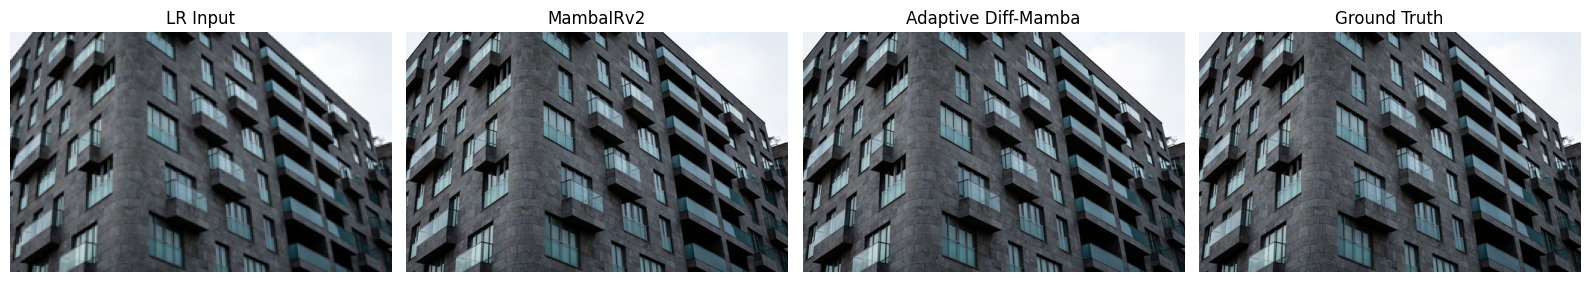

Saved: /kaggle/working/urban100_visual_comparison.png


In [85]:
# ============================================================
# SAVE VISUAL COMPARISON FIGURE
# LR | BASELINE | ADAPTIVE | GT
# ============================================================

import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

# CHANGE THIS TO ANY URBAN100 IMAGE YOU WANT
IMG_NAME = "img_001_SRF_2_LR.png"

LR_DIR = "/kaggle/input/datasets/poorvanshilowanshi/urban100/Urban 100/X2 Urban100/X2/LOW X2 Urban"
HR_DIR = "/kaggle/input/datasets/poorvanshilowanshi/urban100/Urban 100/X2 Urban100/X2/HIGH X2 Urban"

lr_path = os.path.join(LR_DIR, IMG_NAME)
hr_path = os.path.join(HR_DIR, IMG_NAME.replace("_LR.png","_HR.png"))

lr = cv2.cvtColor(cv2.imread(lr_path), cv2.COLOR_BGR2RGB).astype(np.float32)/255.0
hr = cv2.cvtColor(cv2.imread(hr_path), cv2.COLOR_BGR2RGB).astype(np.float32)/255.0

inp = torch.from_numpy(lr).permute(2,0,1).unsqueeze(0).float().cuda()

with torch.no_grad():
    baseline = model(inp)
    adaptive, _, _, _ = two_stage_adaptive_forward(inp, lr)

baseline = baseline.squeeze(0).permute(1,2,0).clamp(0,1).cpu().numpy()
adaptive = adaptive.squeeze(0).permute(1,2,0).clamp(0,1).cpu().numpy()

fig = plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(lr)
plt.title("LR Input")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(baseline)
plt.title("MambaIRv2")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(adaptive)
plt.title("Adaptive Diff-Mamba")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(hr)
plt.title("Ground Truth")
plt.axis("off")

plt.tight_layout()

save_path = "/kaggle/working/urban100_visual_comparison.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

In [86]:
# Show top 10 Urban100 gains

urban_results = sorted(
    urban_results,
    key=lambda x: x["gain"],
    reverse=True
)

for r in urban_results[:10]:
    print(
        r["name"],
        "Gain =", round(r["gain"],4)
    )

NameError: name 'urban_results' is not defined